# SQLStorm StackOverflow — query outputs

`make outputs DB_NAME=stackoverflow_1gb DIR=queries/stackoverflow/SQLStorm STATEMENT_TIMEOUT=60` ran
every StackOverflow SQLStorm query once through `output_runner` and saved its result rows to
`outputs/stackoverflow_1gb/<qid>.txt`. How each file is written matters for everything below:

* psql runs **unaligned** (`-A`, `|` between fields, one header line), streamed through a cursor
  (`FETCH_COUNT=1000`), stdout and stderr together.
* The output is piped through **`head -n 1001`**: header + 1000 *lines*. A result that fits keeps psql's
  `(N rows)` footer; a result that does not loses the footer, and closing the pipe stops the query.
  A result of exactly 1000 rows also loses its footer (1000 rows + header + footer = 1002 lines), so
  "capped" means **≥ 1000 rows**.
* Values are printed raw, so a value containing a newline (post bodies, comments) spans several lines.
  The cap counts lines, not rows, so such results are cut **before** 1000 rows.
* A **60 s** statement timeout writes psql's `ERROR: canceling statement due to statement timeout`
  in place of the rows.

Sections: 1 parse and status, 2 the 1000-row cap, 3 repeats (within one output and across queries),
4 trends against the query text, 5 run time, 6 summary. Export: `csv/sqlstorm_stackoverflow_outputs.csv`.

## 0. Pull outputs → `cache/outputs_cache/`

The output folder is streamed as one gzip tarball over SSH (≈ 210 MB unpacked, git-ignored), together
with each file's exact modification time (used for run time in §5) and the run's `console.log`.
Everything falls back to the cache if the server is unreachable.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, tarfile, time, hashlib, collections
from pathlib import Path
import numpy as np
import pandas as pd

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                                   # demo credential
REMOTE_ROOT = "/home/user01/GreenSQL"
DB = "stackoverflow_1gb"
EXPECT = 11794
MAX_ROWS = 1000                                  # output_runner default (header + 1000 lines kept)
CACHE = Path("cache/outputs_cache")
ODIR = CACHE / DB
QDIR = Path("cache/sqlstorm_cache/stackoverflow/queries")         # from sqlstorm_analysis.ipynb
TIMING = Path("cache/sqlstorm_cache/stackoverflow/logs/query_timing_stackoverflow_1gb.csv")
FEATURES = Path("csv/sqlstorm_stackoverflow_query_features.csv")


def _ssh():
    import paramiko
    cl = paramiko.SSHClient()
    cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
    cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
               timeout=45, banner_timeout=45, auth_timeout=45)
    return cl


def pull():
    ODIR.mkdir(parents=True, exist_ok=True)
    try:
        cl = _ssh()
        try:
            _, out, err = cl.exec_command(f"tar -C {REMOTE_ROOT}/outputs -czf - {DB}")
            with tarfile.open(fileobj=out, mode="r|gz") as tf:
                tf.extractall(CACHE, filter="data")
            _, out, _ = cl.exec_command(f"find {REMOTE_ROOT}/outputs/{DB} -name '*.txt' -printf '%f\\t%T@\\n'")
            (CACHE / f"{DB}.mtimes.tsv").write_bytes(out.read())
            with cl.open_sftp() as sftp, sftp.open(f"{REMOTE_ROOT}/logs/outputs_stackoverflow/console.log") as f:
                (CACHE / f"{DB}.console.log").write_bytes(f.read())
            return "server"
        finally:
            cl.close()
    except Exception as exc:
        if not (CACHE / f"{DB}.mtimes.tsv").exists():
            raise RuntimeError(f"{exc}\nNo output cache at '{CACHE}/'.") from exc
        age_h = (time.time() - (CACHE / f"{DB}.mtimes.tsv").stat().st_mtime) / 3600
        return f"cache ({age_h:.1f} h old; pull failed: {type(exc).__name__})"


SRC = pull()
FILES = sorted(ODIR.glob("*.txt"))
print(f"outputs: {SRC}; {len(FILES)} files ({sum(f.stat().st_size for f in FILES) / 1e6:.0f} MB), "
      f"expected {EXPECT}")
assert len(FILES) == EXPECT, "output folder incomplete"

outputs: server; 11794 files (193 MB), expected 11794


## 1. Parse every output

Per file: **status** (`ok` = footer present, `capped` = 1001 lines and no footer, `timeout` / `error` =
the file starts with a `psql:` error line), the number of columns, the rows (the footer count, or for
a capped file the records found in its 1000 lines), and the records themselves. Records are rebuilt
from lines by counting `|` separators: a line with fewer separators than the header continues on the
next line. The rebuild is checked against the footer count on every file that has one.

In [2]:
FOOT = re.compile(r"^\((\d+) rows?\)$")


def parse(path):
    txt = path.read_bytes().decode("utf-8", "replace")
    L = txt.split("\n")
    if L and L[-1] == "":
        L.pop()
    r = dict(qid=int(path.stem), bytes=path.stat().st_size, out_lines=len(L))
    if L and L[0].startswith("psql:"):
        r["status"] = "timeout" if "statement timeout" in L[0] else "error"
        r["message"] = L[0].split("ERROR:", 1)[-1].strip()
        return r, []
    header = L[0]
    k = header.count("|")
    foot = FOOT.match(L[-1]) if len(L) > 1 else None
    body = L[1:-1] if foot else L[1:]
    recs, cur, seps = [], None, 0
    for line in body:
        cur, seps = (line, line.count("|")) if cur is None else (cur + "\n" + line, seps + line.count("|"))
        if seps >= k:
            recs.append(cur); cur = None
    partial = cur is not None                    # a record cut in half by the cap
    status = "ok" if foot else ("capped" if len(L) == MAX_ROWS + 1 else "other")
    r.update(status=status, header=header, ncol=k + 1,
             rows=int(foot.group(1)) if foot else len(recs), parsed=len(recs), partial=partial,
             multiline=len(recs) + partial < len(body),
             dup_rows=len(recs) - len(set(recs)),
             body_md5=hashlib.md5("\n".join(recs).encode()).hexdigest(),
             full_md5=hashlib.md5(txt.encode()).hexdigest())
    return r, recs


rows, RECS = [], {}
for f in FILES:
    r, recs = parse(f)
    rows.append(r); RECS[r["qid"]] = recs
O = pd.DataFrame(rows).set_index("qid").sort_index()

okf = O[O["status"] == "ok"]
PARSE_OK = (okf["parsed"] == okf["rows"]).mean()
print(O["status"].value_counts().to_string())
print(f"record rebuild matches the footer count on {100 * PARSE_OK:.2f}% of the {len(okf)} files with a "
      f"footer; {int(O['multiline'].sum())} outputs contain multi-line values")

status
ok         9712
capped     2074
timeout       8
record rebuild matches the footer count on 99.78% of the 9712 files with a footer; 207 outputs contain multi-line values


### 1a. Cross-check with the runner's own count

`output_runner` reports a query as FAILED when any of the first 8 KB of its output starts with
`ERROR:` or `psql:`. That also catches **result rows** that start with `ERROR:` — StackOverflow post
titles such as *"ERROR: extra data after last expected column …"* — so its failure count is too high.

In [3]:
con = (CACHE / f"{DB}.console.log").read_text("utf-8", "replace")
RUNNER_FAILED = {int(m) for m in re.findall(r"FAILED (\d+)\.sql", con)}
REAL_FAILED = set(O.index[O["status"].isin(["timeout", "error"])])
FALSE_FAIL = sorted(RUNNER_FAILED - REAL_FAILED)
print(f"runner FAILED: {len(RUNNER_FAILED)};  real timeouts/errors: {len(REAL_FAILED)} "
      f"({', '.join(f'{k} {v}' for k, v in O.loc[list(REAL_FAILED), 'status'].value_counts().items())});  "
      f"false alarms (data rows starting with 'ERROR'): {len(FALSE_FAIL)} -> {FALSE_FAIL}")
print("missed by the runner:", sorted(REAL_FAILED - RUNNER_FAILED) or "none")

runner FAILED: 18;  real timeouts/errors: 8 (timeout 8);  false alarms (data rows starting with 'ERROR'): 10 -> [841, 2784, 5410, 7367, 8914, 23345, 25460, 26933, 29068, 31452]
missed by the runner: none


### 1b. What came back

Row count of every output, binned. The capped bar holds every result of 1000 rows or more.

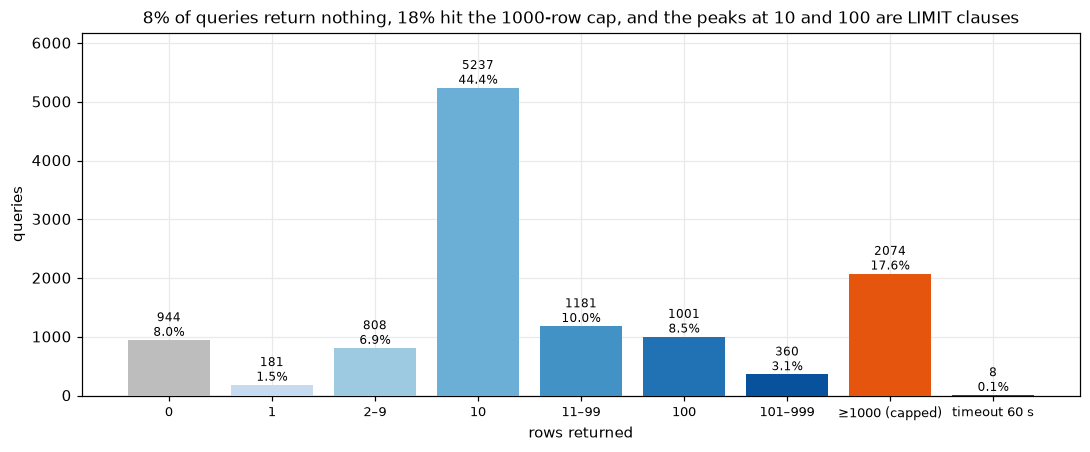

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "savefig.facecolor": "white", "axes.grid": True,
                     "grid.color": "#e9e9e9", "axes.axisbelow": True,
                     "font.size": 9.5, "figure.dpi": 110})
FIG = Path("figures/sqlstorm_outputs"); FIG.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")


CLASSES = ["0", "1", "2–9", "10", "11–99", "100", "101–999", "≥1000 (capped)", "timeout 60 s"]
CCOL = ["#bdbdbd", "#c6dbef", "#9ecae1", "#6baed6", "#4292c6", "#2171b5", "#08519c", "#e6550d", "#a50f15"]


def row_class(r):
    if r.status in ("timeout", "error"):
        return "timeout 60 s"
    if r.status == "capped":
        return "≥1000 (capped)"
    n = r.rows
    return ("0" if n == 0 else "1" if n == 1 else "2–9" if n < 10 else "10" if n == 10 else
            "11–99" if n < 100 else "100" if n == 100 else "101–999")


O["rclass"] = pd.Categorical([row_class(r) for r in O.itertuples()], CLASSES, ordered=True)
RC = O["rclass"].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(range(len(RC)), RC, color=CCOL, zorder=3)
for i, v in enumerate(RC):
    ax.text(i, v, f"{v}\n{100 * v / len(O):.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(RC))); ax.set_xticklabels(CLASSES, rotation=0, fontsize=8.5)
ax.set_ylabel("queries"); ax.set_xlabel("rows returned")
ax.set_ylim(0, RC.max() * 1.18)
ax.set_title(f"{100 * RC['0'] / len(O):.0f}% of queries return nothing, "
             f"{100 * RC['≥1000 (capped)'] / len(O):.0f}% hit the 1000-row cap, and the "
             f"peaks at 10 and 100 are LIMIT clauses", fontsize=11)
fig.tight_layout(); savefig(fig, "rows_returned"); plt.show()

## 2. The 1000-row cap

Which queries hit it, whether they really had 1000 rows, and how that relates to the query's own
`LIMIT`. The LIMIT is the last `LIMIT n` in the SQL (comments stripped), which is the outer one for
almost every SQLStorm query; one in a subquery or CTE only bounds that part.

In [5]:
def outer_limit(sql):
    sql = re.sub(r"--[^\n]*", " ", sql)
    sql = re.sub(r"/\*.*?\*/", " ", sql, flags=re.S)
    m = re.findall(r"\bLIMIT\s+(\d+)", sql, re.I)
    return int(m[-1]) if m else np.nan


O["limit"] = [outer_limit((QDIR / f"{q}.sql").read_text("utf-8", "replace")) for q in O.index]
cap = O[O["status"] == "capped"]
CAP_N = len(cap)
CAP_FULL = int((cap["parsed"] >= MAX_ROWS).sum())        # 1000 complete records in the file
CAP_SHORT = CAP_N - CAP_FULL                             # cut early by multi-line values
CAP_LIM = cap["limit"].value_counts(dropna=False)
print(f"capped: {CAP_N} of {len(O)} ({100 * CAP_N / len(O):.1f}%)")
print(f"  {CAP_FULL} with 1000 complete records (true result >= 1000 rows; = 1000 is possible for "
      f"{int((cap['limit'] == 1000).sum())} with LIMIT 1000)")
print(f"  {CAP_SHORT} cut before 1000 records because values span lines "
      f"(median {cap.loc[cap['parsed'] < MAX_ROWS, 'parsed'].median():.0f} records kept)")
print("  outer LIMIT of capped queries:", ", ".join(f"{'none' if pd.isna(k) else int(k)}: {v}"
                                                  for k, v in CAP_LIM.items()))

capped: 2074 of 11794 (17.6%)
  1974 with 1000 complete records (true result >= 1000 rows; = 1000 is possible for 5 with LIMIT 1000)
  100 cut before 1000 records because values span lines (median 41 records kept)
  outer LIMIT of capped queries: none: 1940, 10: 65, 5: 21, 1: 19, 100: 14, 50: 9, 1000: 5, 20: 1


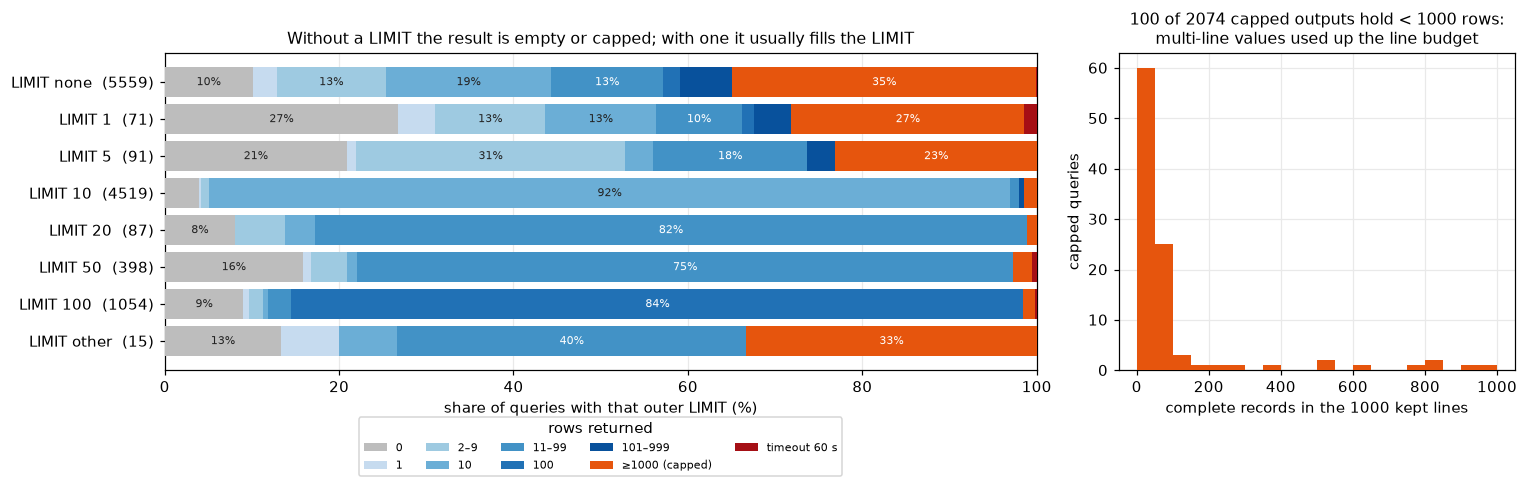

queries with a LIMIT that finished: 6096; returned exactly LIMIT rows: 89%, fewer: 9%, more (LIMIT inside a subquery): 123


In [6]:
LIM_ORDER = ["none", "1", "5", "10", "20", "50", "100", "other"]


def lim_group(v):
    if pd.isna(v):
        return "none"
    v = int(v)
    return str(v) if str(v) in LIM_ORDER else "other"


O["lim_g"] = pd.Categorical(O["limit"].map(lim_group), LIM_ORDER, ordered=True)
CT = pd.crosstab(O["lim_g"], O["rclass"], normalize="index").reindex(columns=CLASSES) * 100
NQ = O["lim_g"].value_counts().reindex(LIM_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0]
left = np.zeros(len(CT))
for c, col in zip(CLASSES, CCOL):
    ax.barh(range(len(CT)), CT[c], left=left, color=col, label=c, zorder=3)
    for i, (l, v) in enumerate(zip(left, CT[c])):
        if v >= 7:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=7.5,
                    color="white" if col in CCOL[4:] else "#222")
    left += CT[c].to_numpy()
ax.set_yticks(range(len(CT))); ax.set_yticklabels([f"LIMIT {g}  ({n})" for g, n in zip(LIM_ORDER, NQ)])
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel("share of queries with that outer LIMIT (%)")
ax.legend(ncol=5, fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.13), title="rows returned")
ax.set_title("Without a LIMIT the result is empty or capped; with one it usually fills the LIMIT",
             fontsize=10.5)

ax = axes[1]
short = cap.loc[cap["parsed"] < MAX_ROWS, "parsed"]
ax.hist(short, bins=np.arange(0, 1001, 50), color="#e6550d", zorder=3)
ax.set_xlabel("complete records in the 1000 kept lines"); ax.set_ylabel("capped queries")
ax.set_title(f"{CAP_SHORT} of {CAP_N} capped outputs hold < 1000 rows:\nmulti-line values used up the "
             f"line budget", fontsize=10.5)
fig.tight_layout(); savefig(fig, "cap_vs_limit"); plt.show()

lim = O[O["status"] == "ok"].dropna(subset=["limit"])
FILL = (lim["rows"] == lim["limit"]).mean()
print(f"queries with a LIMIT that finished: {len(lim)}; returned exactly LIMIT rows: {100 * FILL:.0f}%, "
      f"fewer: {100 * (lim['rows'] < lim['limit']).mean():.0f}%, more (LIMIT inside a subquery): "
      f"{int((lim['rows'] > lim['limit']).sum())}")

## 3. Repeats

Two kinds: **identical rows inside one output** (a join that fans out, a missing DISTINCT), and
**identical results across queries** (the same query under two names, or different SQL with the same answer). For capped outputs only the kept
part is compared.

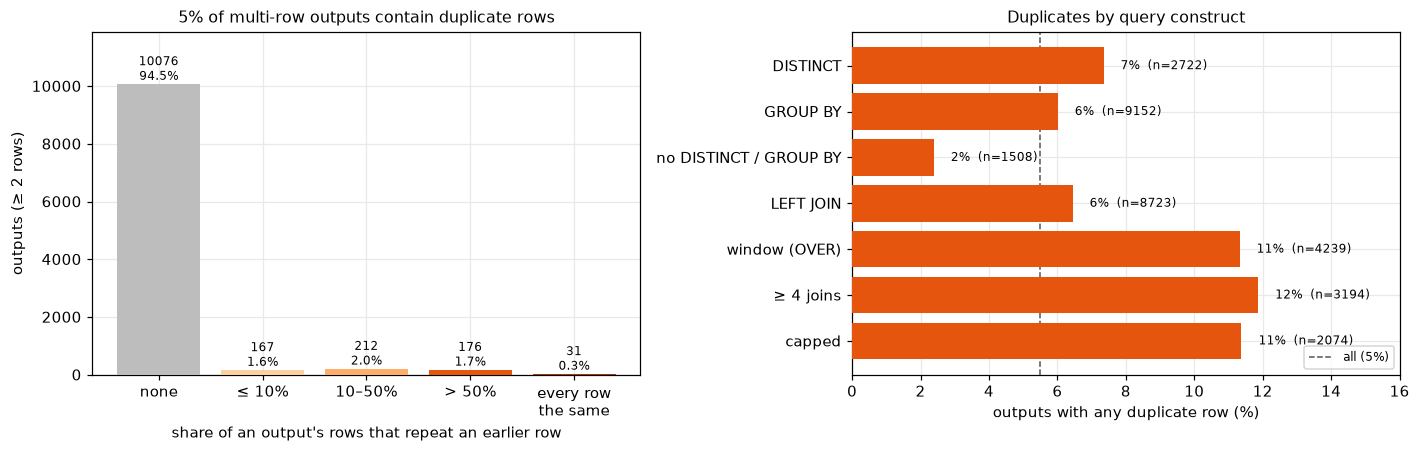

In [7]:
multi = O[O["status"].isin(["ok", "capped"]) & (O["parsed"] >= 2)].copy()
multi["dup_frac"] = multi["dup_rows"] / multi["parsed"]
DUP_ANY = (multi["dup_rows"] > 0).mean()
multi["distinct"] = multi["parsed"] - multi["dup_rows"]
labs = ["none", "≤ 10%", "10–50%", "> 50%", "every row\nthe same"]
multi["dup_cls"] = pd.Categorical(np.select(
    [multi["dup_rows"] == 0, multi["distinct"] == 1, multi["dup_frac"] <= 0.1, multi["dup_frac"] <= 0.5],
    [labs[0], labs[4], labs[1], labs[2]], labs[3]), labs)
DC = multi["dup_cls"].value_counts().reindex(labs)

F = pd.read_csv(FEATURES).set_index("qid")
mf = multi.join(F, how="left")
grp = {"DISTINCT": mf["has_distinct"], "GROUP BY": mf["has_group"], "no DISTINCT / GROUP BY":
       ~(mf["has_distinct"] | mf["has_group"]), "LEFT JOIN": mf["join_left"], "window (OVER)":
       mf["has_window"], "≥ 4 joins": mf["n_join"] >= 4, "capped": mf["status"] == "capped"}
DG = pd.Series({k: 100 * (mf.loc[m.astype(bool), "dup_rows"] > 0).mean() for k, m in grp.items()})
NG = pd.Series({k: int(m.astype(bool).sum()) for k, m in grp.items()})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.bar(range(len(DC)), DC, color=["#bdbdbd", "#fdd0a2", "#fdae6b", "#e6550d", "#a63603"], zorder=3)
for i, v in enumerate(DC):
    ax.text(i, v, f"{v}\n{100 * v / len(multi):.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(DC))); ax.set_xticklabels(labs)
ax.set_xlabel("share of an output's rows that repeat an earlier row"); ax.set_ylabel("outputs (≥ 2 rows)")
ax.set_ylim(0, DC.max() * 1.18)
ax.set_title(f"{100 * DUP_ANY:.0f}% of multi-row outputs contain duplicate rows", fontsize=10.5)
ax = axes[1]
ax.barh(range(len(DG)), DG, color="#e6550d", zorder=3)
ax.axvline(100 * DUP_ANY, color="#555", ls="--", lw=1, label=f"all ({100 * DUP_ANY:.0f}%)")
for i, (v, n) in enumerate(zip(DG, NG)):
    ax.text(v + 0.5, i, f"{v:.0f}%  (n={n})", va="center", fontsize=8)
ax.set_yticks(range(len(DG))); ax.set_yticklabels(DG.index); ax.invert_yaxis()
ax.set_xlim(0, max(DG.max() * 1.35, 10)); ax.legend(loc="lower right", fontsize=8)
ax.set_xlabel("outputs with any duplicate row (%)")
ax.set_title("Duplicates by query construct", fontsize=10.5)
fig.tight_layout(); savefig(fig, "duplicate_rows"); plt.show()

### 3a. Outputs where every row is the same

Outputs of two or more rows in which every row is an exact copy of the first one: the whole
answer is a single row repeated. For a capped output this holds for the 1000 kept rows. A NULL
prints as an empty field, so the share of empty fields shows how much of that row is NULL.

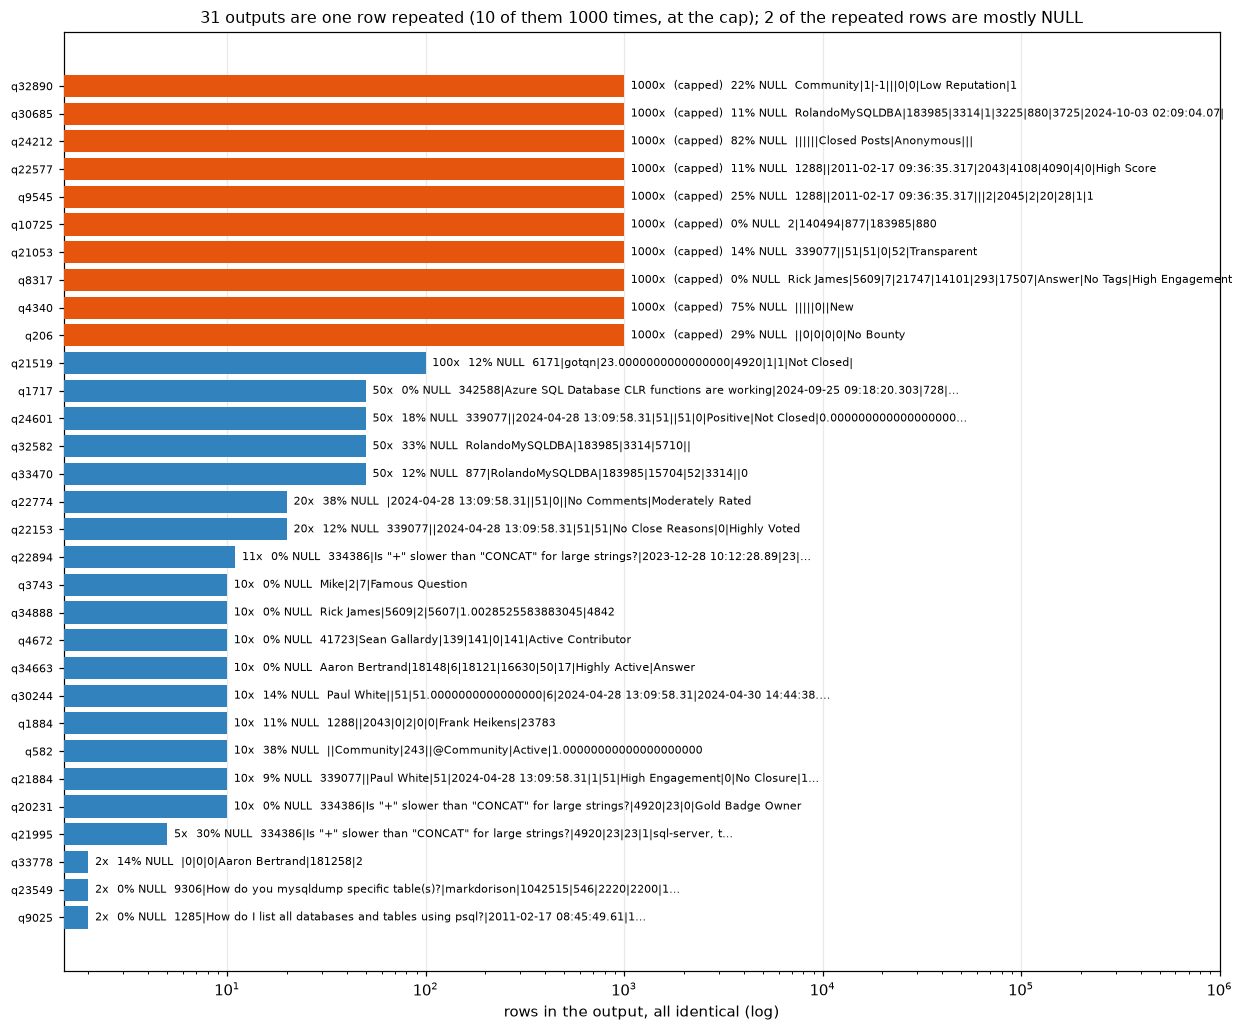

every row identical: 31 of 10662 multi-row outputs (0.29%); 10 capped, 12 fill their LIMIT with copies
constructs among them: window (OVER) 27, GROUP BY 27, DISTINCT 12, LEFT JOIN 31, CTE 31; median joins 4
nearly so (2-3 distinct rows among >= 10): 23 more outputs
       status    rows  ncol  limit  n_join  has_window  has_group  has_distinct  empty_fields
qid                                                                                          
206    capped  1000.0   7.0    NaN       3        True       True         False          0.29
4340   capped  1000.0   8.0   10.0       4        True       True          True          0.75
8317   capped  1000.0  10.0    NaN       6        True       True          True          0.00
21053  capped  1000.0   7.0    NaN       3        True       True          True          0.14
10725  capped  1000.0   5.0    NaN       3       False       True         False          0.00
9545   capped  1000.0  12.0    NaN       4        True       True         Fa

In [8]:
SAME = multi[multi["distinct"] == 1].join(F[["n_join", "join_left", "has_window", "has_group",
                                                "has_distinct", "is_cte"]], how="left")
SAME["row"] = [RECS[q][0] for q in SAME.index]
SAME["empty_fields"] = [sum(v == "" for v in r.split("|")) / n for r, n in zip(SAME["row"], SAME["ncol"])]
SAME["fills_limit"] = SAME["rows"] == SAME["limit"]
NEAR = multi[(multi["distinct"] > 1) & (multi["distinct"] <= 3) & (multi["parsed"] >= 10)]
N_SAME, N_SAME_CAP = len(SAME), int((SAME["status"] == "capped").sum())

fig, ax = plt.subplots(figsize=(12, 0.26 * N_SAME + 1.4))
S = SAME.sort_values("parsed")
y = np.arange(len(S))
ax.barh(y, S["parsed"], color=np.where(S["status"] == "capped", "#e6550d", "#3182bd"), zorder=3)
for yy, r in zip(y, S.itertuples()):
    tag = (f"{int(r.parsed)}x  " + ("(capped)  " if r.status == "capped" else "") +
           f"{100 * r.empty_fields:.0f}% NULL  " + r.row[:80].replace("\n", " ") + ("…" if len(r.row) > 80 else ""))
    ax.text(r.parsed * 1.08, yy, tag, va="center", fontsize=7)
ax.set_xscale("log"); ax.set_xlim(1.5, 1e6)
ax.set_yticks(y); ax.set_yticklabels([f"q{q}" for q in S.index], fontsize=7.5)
ax.set_xlabel("rows in the output, all identical (log)")
ax.set_title(f"{N_SAME} outputs are one row repeated ({N_SAME_CAP} of them 1000 times, at the cap); "
             f"{int((SAME['empty_fields'] >= 0.5).sum())} of the repeated rows are mostly NULL", fontsize=10.5)
ax.grid(axis="y", visible=False)
fig.tight_layout(); savefig(fig, "all_rows_identical"); plt.show()

print(f"every row identical: {N_SAME} of {len(multi)} multi-row outputs ({100 * N_SAME / len(multi):.2f}%); "
      f"{N_SAME_CAP} capped, {int(SAME['fills_limit'].sum())} fill their LIMIT with copies")
print("constructs among them: " + ", ".join(f"{lbl} {int(SAME[c].sum())}" for lbl, c in
      [("window (OVER)", "has_window"), ("GROUP BY", "has_group"), ("DISTINCT", "has_distinct"),
       ("LEFT JOIN", "join_left"), ("CTE", "is_cte")]) + f"; median joins {SAME['n_join'].median():.0f}")
print(f"nearly so (2-3 distinct rows among >= 10): {len(NEAR)} more outputs")
display_cols = ["status", "rows", "ncol", "limit", "n_join", "has_window", "has_group", "has_distinct", "empty_fields"]
print(SAME.sort_values("parsed", ascending=False)[display_cols].round(2).to_string())

### 3b. Fully identical outputs across queries

The strict test: two queries match when their output files are **byte-identical** — same header,
every row in the same order, same footer. Capped outputs match on their 1000 kept rows; the 8
timeouts are left out. Each match is then checked against the SQL in `cache/sqlstorm_cache/`: the SQL
is normalised (SQLStorm header comment, `EXPLAIN (…)` wrapper and comments removed, whitespace
collapsed, lower-cased) so a group can be split into **copies of the same query** and **different
queries with the same answer**.

In [9]:
def norm_sql(txt):
    s = re.sub(r"--[^\n]*", " ", txt)
    s = re.sub(r"/\*.*?\*/", " ", s, flags=re.S)
    s = re.sub(r"(?is)^\s*EXPLAIN\s*\([^)]*\)", " ", s)
    return re.sub(r"\s+", " ", s).strip().rstrip(";").strip().lower()


SQL_RAW = {q: (QDIR / f"{q}.sql").read_text("utf-8", "replace") for q in O.index}
SQLN = pd.Series({q: norm_sql(t) for q, t in SQL_RAW.items()}).sort_index()
O["sql_md5"] = SQLN.map(lambda s: hashlib.md5(s.encode()).hexdigest())

# 1) the corpus itself: identical SQL under different query names
SQL_SETS = O.groupby("sql_md5").filter(lambda x: len(x) > 1)
N_SQL_SETS, N_SQL_DUP = SQL_SETS["sql_md5"].nunique(), len(SQL_SETS)
# ... and whether copies of one query always produce the same file (determinism)
INCONS = SQL_SETS[SQL_SETS["status"] != "timeout"].groupby("sql_md5")["full_md5"].nunique()
INCONS = INCONS[INCONS > 1]

# 2) byte-identical outputs
fo = O[O["status"].isin(["ok", "capped"])]
gsize = fo.groupby("full_md5").size()
IDQ = fo[fo["full_md5"].map(gsize) > 1].copy()
order = (IDQ.groupby("full_md5").agg(n=("status", "size"), first=("status", lambda s: s.index.min()))
         .sort_values(["n", "first"], ascending=[False, True]))
IDQ["group"] = IDQ["full_md5"].map({h: f"G{i + 1}" for i, h in enumerate(order.index)})
IDQ["n_sql"] = IDQ.groupby("group")["sql_md5"].transform("nunique")
IDQ["kind"] = np.where(IDQ["n_sql"] == 1, "same SQL (copies)",
                       np.where(IDQ.groupby("group")["sql_md5"].transform("size") == IDQ["n_sql"],
                                "different SQL", "copies + different SQL"))
O["ident_group"] = IDQ["group"]

print(f"corpus: {len(O)} queries but {SQLN.nunique()} distinct SQL texts — {N_SQL_DUP} queries are in "
      f"{N_SQL_SETS} sets of copies (largest {SQL_SETS.groupby('sql_md5').size().max()})")
blk = pd.cut(SQL_SETS.index, [0, 5000, 10000, 15000, 20000, 25000, 40000],
             labels=["≤5k", "5–10k", "10–15k", "15–20k", "20–25k", ">25k"]).value_counts().sort_index()
print("copies by query-number block: " + ", ".join(f"{k}: {v}" for k, v in blk.items())
      + f"  ({100 * blk['15–20k'] / blk.sum():.0f}% sit in queries 15000-19999)")
print(f"copies that disagree on output: {len(INCONS)} (all copies of a query return byte-identical files)"
      if len(INCONS) == 0 else f"copies that disagree on output: {len(INCONS)} sets -> nondeterministic results")
print(f"byte-identical outputs: {IDQ['group'].nunique()} groups covering {len(IDQ)} queries "
      f"({100 * len(IDQ) / len(fo):.1f}% of finished queries); {int((IDQ['rows'] == 0).groupby(IDQ['group']).first().sum())} "
      f"groups are empty results, {int((IDQ['status'] == 'capped').groupby(IDQ['group']).first().sum())} capped")
print(IDQ.groupby("group")["kind"].first().value_counts().to_string())

corpus: 11794 queries but 9519 distinct SQL texts — 2727 queries are in 452 sets of copies (largest 96)
copies by query-number block: ≤5k: 0, 5–10k: 0, 10–15k: 138, 15–20k: 2589, 20–25k: 0, >25k: 0  (95% sit in queries 15000-19999)
copies that disagree on output: 0 (all copies of a query return byte-identical files)
byte-identical outputs: 452 groups covering 3050 queries (25.9% of finished queries); 5 groups are empty results, 20 capped
kind
same SQL (copies)         258
copies + different SQL    125
different SQL              69


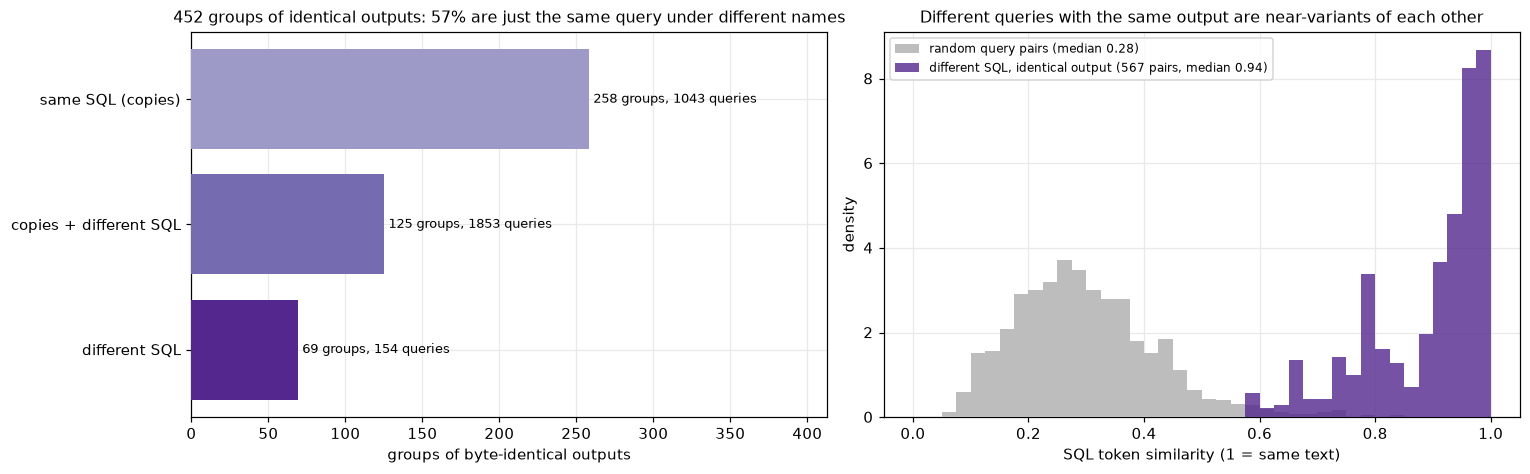

different-SQL pairs with identical output: same outer LIMIT 86%, same tables 99%, similarity < 0.75: 66


In [10]:
import difflib, itertools, random


def sql_tokens(q):
    return re.findall(r"\w+|[^\w\s]", SQLN[q])


def sql_sim(q1, q2):
    """token-level similarity of two normalised queries (difflib ratio, 1 = identical)"""
    return difflib.SequenceMatcher(None, sql_tokens(q1), sql_tokens(q2), autojunk=False).ratio()


pairs = []
for g, x in IDQ.groupby("group"):
    reps = x.drop_duplicates("sql_md5").index                  # one query per distinct SQL text
    for q1, q2 in itertools.combinations(sorted(reps), 2):
        pairs.append(dict(group=g, q1=q1, q2=q2, sim=sql_sim(q1, q2),
                          same_limit=(O.at[q1, "limit"] == O.at[q2, "limit"]) or
                                     (pd.isna(O.at[q1, "limit"]) and pd.isna(O.at[q2, "limit"])),
                          same_tables=bool((F.loc[q1].filter(like="tbl_") == F.loc[q2].filter(like="tbl_")).all())))
PAIRS = pd.DataFrame(pairs)
rng = random.Random(20261001)
uniq = list(fo.drop_duplicates("sql_md5").index)
RAND = pd.Series([sql_sim(*rng.sample(uniq, 2)) for _ in range(1000)])

KIND_ORDER = ["same SQL (copies)", "copies + different SQL", "different SQL"]
KC = IDQ.groupby("group")["kind"].first().value_counts().reindex(KIND_ORDER).fillna(0).astype(int)
KQ = IDQ["kind"].value_counts().reindex(KIND_ORDER).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
ax = axes[0]
kcol = ["#9e9ac8", "#756bb1", "#54278f"]
ax.barh(range(3), KC, color=kcol, zorder=3)
for i, (g, q) in enumerate(zip(KC, KQ)):
    ax.text(g + 3, i, f"{g} groups, {q} queries", va="center", fontsize=8.5)
ax.set_yticks(range(3)); ax.set_yticklabels(KIND_ORDER); ax.invert_yaxis()
ax.set_xlim(0, KC.max() * 1.6); ax.set_xlabel("groups of byte-identical outputs")
ax.set_title(f"{IDQ['group'].nunique()} groups of identical outputs: {100 * KC.iloc[0] / KC.sum():.0f}% are "
             f"just the same query under different names", fontsize=10.5)
ax = axes[1]
b = np.linspace(0, 1, 41)
ax.hist(RAND, bins=b, color="#bdbdbd", density=True, label=f"random query pairs (median {RAND.median():.2f})",
        zorder=3)
ax.hist(PAIRS["sim"], bins=b, color="#54278f", alpha=0.8, density=True,
        label=f"different SQL, identical output ({len(PAIRS)} pairs, median {PAIRS['sim'].median():.2f})", zorder=3)
ax.set_xlabel("SQL token similarity (1 = same text)"); ax.set_ylabel("density"); ax.legend(fontsize=8)
ax.set_title("Different queries with the same output are near-variants of each other", fontsize=10.5)
fig.tight_layout(); savefig(fig, "identical_outputs"); plt.show()
print(f"different-SQL pairs with identical output: same outer LIMIT {100 * PAIRS['same_limit'].mean():.0f}%, "
      f"same tables {100 * PAIRS['same_tables'].mean():.0f}%, similarity < 0.75: {int((PAIRS['sim'] < 0.75).sum())}")

#### Query-name combinations with the same output

One line per group, largest first. In `queries`, `=` joins copies of the same SQL and `|` separates
different SQL texts. The full list is exported to `csv/sqlstorm_stackoverflow_identical_outputs.csv`;
`show_group("G12")` prints a group's output head and SQL, and `sql_diff(q1, q2)` diffs two queries.

In [11]:
def combo(x):
    parts = [" = ".join(str(q) for q in sorted(g.index)) for _, g in
             sorted(x.groupby("sql_md5"), key=lambda kv: kv[1].index.min())]
    return " | ".join(parts)


IDENT = (IDQ.groupby("group")
         .apply(lambda x: pd.Series(dict(n_queries=len(x), n_sql=x["sql_md5"].nunique(), kind=x["kind"].iloc[0],
                                         rows=int(x["rows"].iloc[0]), capped=x["status"].iloc[0] == "capped",
                                         ncol=int(x["ncol"].iloc[0]),
                                         sim_min=PAIRS.loc[PAIRS["group"] == x.name, "sim"].min(),
                                         queries=combo(x), header=x["header"].iloc[0])), include_groups=False)
         .loc[[f"G{i + 1}" for i in range(len(order))]])
IDENT.to_csv("csv/sqlstorm_stackoverflow_identical_outputs.csv")

import textwrap


def list_groups(T, title):
    print(title)
    for g, r in T.iterrows():
        head = (f"{g:>5}  {r.n_queries:>2} queries, {r.n_sql} SQL, {r.rows} rows" + (" (capped)" if r.capped else "")
                + (f", similarity >= {r.sim_min:.2f}" if r.n_sql > 1 else ""))
        print(head)
        print(textwrap.fill(r.queries, 120, initial_indent=" " * 7, subsequent_indent=" " * 7))
    print()


list_groups(IDENT.head(10), "largest groups:")
list_groups(IDENT[IDENT["kind"] == "different SQL"].sort_values("sim_min").head(15),
            "groups made only of different SQL (no copies), least similar first:")

largest groups:
   G1  98 queries, 2 SQL, 10 rows, similarity >= 0.97
       15027 = 15043 = 15063 = 15147 = 15199 = 15243 = 15319 = 15324 = 15325 = 15386 = 15396 = 15427 = 15446 = 15494 =
       15506 = 15644 = 15663 = 15784 = 15836 = 15847 = 15849 = 15850 = 15954 = 15987 = 16003 = 16019 = 16045 = 16106 =
       16139 = 16148 = 16173 = 16364 = 16447 = 16504 = 16563 = 16594 = 16601 = 16610 = 16772 = 16787 = 16822 = 16885 =
       16942 = 17025 = 17080 = 17145 = 17157 = 17177 = 17230 = 17262 = 17297 = 17495 = 17588 = 17697 = 17710 = 17727 =
       17784 = 17870 = 17888 = 17902 = 17941 = 17989 = 18053 = 18122 = 18133 = 18261 = 18282 = 18289 = 18308 = 18393 =
       18414 = 18459 = 18535 = 18542 = 18545 = 18700 = 18827 = 18905 = 18974 = 18976 = 18980 = 19021 = 19120 = 19201 =
       19227 = 19250 = 19267 = 19313 = 19324 = 19364 = 19416 = 19436 = 19654 = 19803 = 19892 = 19920 | 16207 = 19334
   G2  67 queries, 4 SQL, 10 rows, similarity >= 0.68
       15015 = 15068 = 15117 = 15118 = 15149 

In [12]:
def show_group(g, n_rows=3):
    """output head and the distinct SQL texts of one identical-output group"""
    x = IDQ[IDQ["group"] == g]
    q0 = x.index.min()
    print(f"{g}: {len(x)} queries, {x['sql_md5'].nunique()} distinct SQL, {int(x['rows'].iloc[0])} rows"
          f"{' (capped)' if x['status'].iloc[0] == 'capped' else ''}\n  {IDENT.at[g, 'queries']}\n")
    print("\n".join((ODIR / f"{q0}.txt").read_text("utf-8").split("\n")[:n_rows + 1]), "\n")
    for _, s in sorted(x.groupby("sql_md5"), key=lambda kv: kv[1].index.min()):
        print(f"-- {', '.join(map(str, sorted(s.index)))}\n{body_sql(s.index.min())}\n")


def body_sql(q):
    return "\n".join(l for l in SQL_RAW[q].split("\n")
                     if not l.startswith("-- SQLStorm") and not l.upper().startswith("EXPLAIN (")).strip()


def sql_diff(q1, q2, context=1, max_lines=60):
    d = list(difflib.unified_diff(body_sql(q1).split("\n"), body_sql(q2).split("\n"),
                                  f"{q1}.sql", f"{q2}.sql", n=context, lineterm=""))
    print("\n".join(d[:max_lines]) + (f"\n… {len(d) - max_lines} more diff lines" if len(d) > max_lines else ""))


low = PAIRS.sort_values("sim").iloc[0]
print(f"least similar pair with identical output: {low.q1} vs {low.q2} ({low.group}, similarity {low.sim:.2f})\n")
sql_diff(int(low.q1), int(low.q2))

least similar pair with identical output: 16241 vs 17819 (G7, similarity 0.58)

--- 16241.sql
+++ 17819.sql
@@ -5,5 +5,5 @@
     u.DisplayName AS OwnerDisplayName,
-    (SELECT COUNT(*) FROM Comments c WHERE c.PostId = p.Id) AS CommentCount,
-    (SELECT COUNT(*) FROM Votes v WHERE v.PostId = p.Id AND v.VoteTypeId = 2) AS UpVoteCount,
-    (SELECT COUNT(*) FROM Votes v WHERE v.PostId = p.Id AND v.VoteTypeId = 3) AS DownVoteCount
+    COUNT(c.Id) AS CommentCount,
+    COALESCE(SUM(CASE WHEN v.VoteTypeId = 2 THEN 1 ELSE 0 END), 0) AS UpVoteCount,
+    COALESCE(SUM(CASE WHEN v.VoteTypeId = 3 THEN 1 ELSE 0 END), 0) AS DownVoteCount
 FROM 
@@ -12,6 +12,12 @@
     Users u ON p.OwnerUserId = u.Id
+LEFT JOIN 
+    Comments c ON p.Id = c.PostId
+LEFT JOIN 
+    Votes v ON p.Id = v.PostId
 WHERE 
     p.PostTypeId = 1
+GROUP BY 
+    p.Id, p.Title, p.CreationDate, u.DisplayName
 ORDER BY 
     p.CreationDate DESC
-LIMIT 10;
+FETCH FIRST 10 ROWS ONLY;


#### Same output, different SQL — different cost?

Energy and time of each query's single measured copy in the SQLStorm run (warm, 2.5 GHz, package
RAPL). The copies give a free noise floor: they are the same SQL measured under different names, so
their spread is pure measurement noise. Different SQL that returns the same rows is compared
against that floor, per pair and per group (cheapest vs most expensive SQL text, each the median
of its copies).

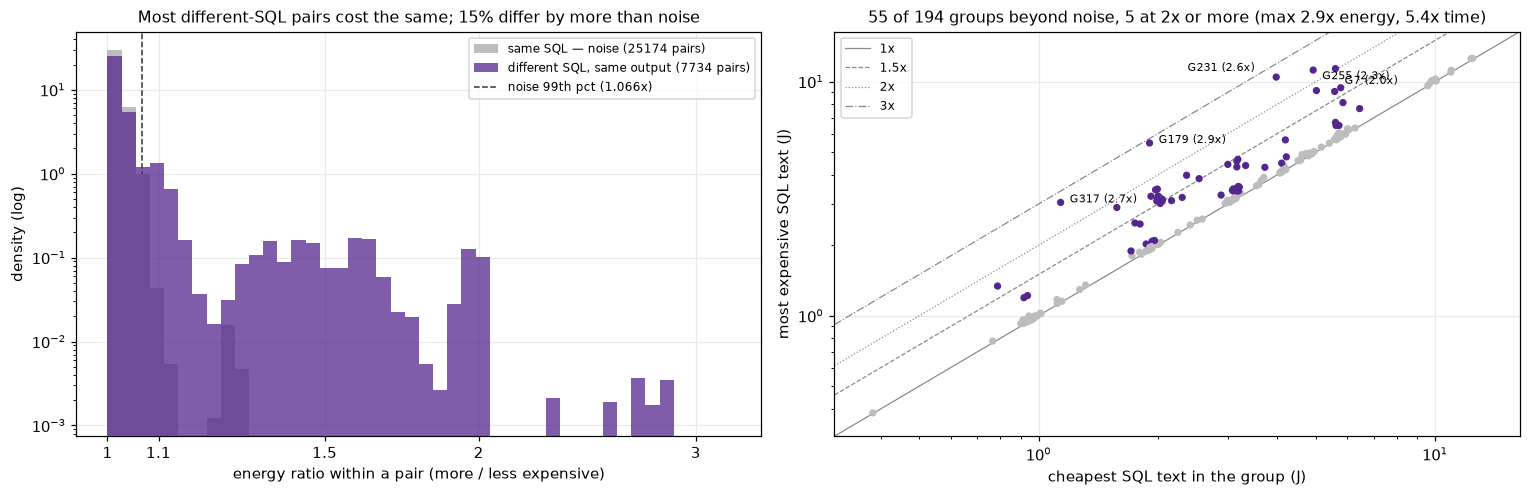

noise between copies: median 1.012x, 99th pct 1.066x energy;  different SQL: median 1.015x, 90th pct 1.11x
per group, cheapest vs dearest SQL: >= 1.1x in 48, >= 1.5x in 21, >= 2x in 5 of 194 groups; time and energy ratios agree (log r = 0.91)
running the cheapest instead of the dearest text in every group: 654 J vs 738 J (11% less)

       n_sql  q_cheap  E_min  t_min  q_dear  E_max  t_max    rE    rt
group                                                                
G179       4    15786   1.90   0.18   16674   5.47   1.00  2.87  5.42
G317       2    15388   1.14   0.12   19317   3.05   0.31  2.68  2.59
G231       2    16023   3.97   0.75   17599  10.46   1.86  2.63  2.50
G255       2     9312   4.92   0.55    6530  11.21   2.00  2.28  3.61
G7         9    17819   5.60   1.03   16241  11.37   1.70  2.03  1.65
G117       6    15920   1.57   0.15   17876   2.90   0.54  1.84  3.49
G326       2    19911   5.02   0.92   15619   9.16   1.34  1.82  1.46
G64        4    16037   1.97   0.22

In [13]:
TM = pd.read_csv(TIMING)
TM = TM[TM["phase"] == "measured"].copy()
TM["qid"] = TM["query"].str.extract(r"(\d+)\.sql$")[0].astype(int)
TM = TM.drop_duplicates("qid", keep="last").set_index("qid")
CC = IDQ.join(TM[["rapl_pkg_j", "elapsed_sec", "failed"]], how="inner")
CC = CC[(CC["failed"] != 1) & (CC["rapl_pkg_j"] > 0)]               # passing SQLStorm measurements only


def pair_ratios(same):
    out = []
    for g, x in CC.groupby("group"):
        for a, b in itertools.combinations(x.index, 2):
            if (x.at[a, "sql_md5"] == x.at[b, "sql_md5"]) == same:
                ea, eb, ta, tb = x.at[a, "rapl_pkg_j"], x.at[b, "rapl_pkg_j"], x.at[a, "elapsed_sec"], x.at[b, "elapsed_sec"]
                out.append(dict(group=g, a=a, b=b, rE=max(ea, eb) / min(ea, eb), rt=max(ta, tb) / min(ta, tb)))
    return pd.DataFrame(out)


NOISE, DIFF = pair_ratios(True), pair_ratios(False)
NOISE_Q99 = NOISE["rE"].quantile(0.99)
VAR = (CC.groupby(["group", "sql_md5"])
       .agg(E=("rapl_pkg_j", "median"), t=("elapsed_sec", "median"), q=("rapl_pkg_j", lambda s: s.index.min())))
VG = VAR.groupby(level=0).agg(n_sql=("E", "size"), E_min=("E", "min"), E_max=("E", "max"),
                              t_min=("t", "min"), t_max=("t", "max"))
VG = VG[VG["n_sql"] > 1].copy()
VG["rE"], VG["rt"] = VG["E_max"] / VG["E_min"], VG["t_max"] / VG["t_min"]
VG["q_cheap"] = [VAR.loc[g].sort_values("E")["q"].iloc[0] for g in VG.index]
VG["q_dear"] = [VAR.loc[g].sort_values("E")["q"].iloc[-1] for g in VG.index]
REAL = VG[VG["rE"] > NOISE_Q99]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]
b = np.logspace(0, np.log10(3.2), 45)
ax.hist(NOISE["rE"], bins=b, density=True, color="#bdbdbd", label=f"same SQL — noise ({len(NOISE)} pairs)", zorder=3)
ax.hist(DIFF["rE"], bins=b, density=True, color="#54278f", alpha=0.75,
        label=f"different SQL, same output ({len(DIFF)} pairs)", zorder=3)
ax.axvline(NOISE_Q99, color="#333", ls="--", lw=1, label=f"noise 99th pct ({NOISE_Q99:.3f}x)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks([1, 1.1, 1.5, 2, 3]); ax.set_xticklabels(["1", "1.1", "1.5", "2", "3"])
ax.set_xlabel("energy ratio within a pair (more / less expensive)"); ax.set_ylabel("density (log)")
ax.legend(fontsize=8)
ax.set_title(f"Most different-SQL pairs cost the same; {100 * (DIFF['rE'] > NOISE_Q99).mean():.0f}% "
             f"differ by more than noise", fontsize=10.5)
ax = axes[1]
ax.scatter(VG["E_min"], VG["E_max"], s=14, color=np.where(VG["rE"] > NOISE_Q99, "#54278f", "#bdbdbd"), zorder=3)
lim = [VG["E_min"].min() * 0.8, VG["E_max"].max() * 1.3]
for r, ls in [(1, "-"), (1.5, "--"), (2, ":"), (3, "-.")]:
    ax.plot(lim, [l * r for l in lim], color="#888", lw=0.8, ls=ls, label=f"{r}x")
for (g, r), off in zip(VG.sort_values("rE", ascending=False).head(5).iterrows(),
                       [(6, 0), (6, 0), (-58, 4), (6, -6), (6, -10)]):
    ax.annotate(f"{g} ({r.rE:.1f}x)", (r.E_min, r.E_max), fontsize=7.5, xytext=off, textcoords="offset points")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("cheapest SQL text in the group (J)"); ax.set_ylabel("most expensive SQL text (J)")
ax.legend(fontsize=8, loc="upper left")
ax.set_title(f"{len(REAL)} of {len(VG)} groups beyond noise, {int((VG['rE'] >= 2).sum())} at 2x or more "
             f"(max {VG['rE'].max():.1f}x energy, {VG['rt'].max():.1f}x time)", fontsize=10.5)
fig.tight_layout(); savefig(fig, "identical_output_cost"); plt.show()

print(f"noise between copies: median {NOISE['rE'].median():.3f}x, 99th pct {NOISE_Q99:.3f}x energy;  "
      f"different SQL: median {DIFF['rE'].median():.3f}x, 90th pct {DIFF['rE'].quantile(0.9):.2f}x")
print(f"per group, cheapest vs dearest SQL: >= 1.1x in {int((VG['rE'] >= 1.1).sum())}, >= 1.5x in "
      f"{int((VG['rE'] >= 1.5).sum())}, >= 2x in {int((VG['rE'] >= 2).sum())} of {len(VG)} groups; "
      f"time and energy ratios agree (log r = {np.corrcoef(np.log(VG['rE']), np.log(VG['rt']))[0, 1]:.2f})")
print(f"running the cheapest instead of the dearest text in every group: {VG['E_min'].sum():.0f} J vs "
      f"{VG['E_max'].sum():.0f} J ({100 * (1 - VG['E_min'].sum() / VG['E_max'].sum()):.0f}% less)\n")
print(VG.sort_values("rE", ascending=False).head(10)[["n_sql", "q_cheap", "E_min", "t_min", "q_dear", "E_max",
                                                     "t_max", "rE", "rt"]].round(2).to_string())
top = VG.sort_values("rE", ascending=False).iloc[0]
print(f"\n{top.name}: {int(top.q_cheap)} ({top.E_min:.2f} J) vs {int(top.q_dear)} ({top.E_max:.2f} J)")
sql_diff(int(top.q_cheap), int(top.q_dear), max_lines=40)

#### Looser: the same rows under any column names

The same comparison on the rows only, ignoring the header, so renamed columns still match.

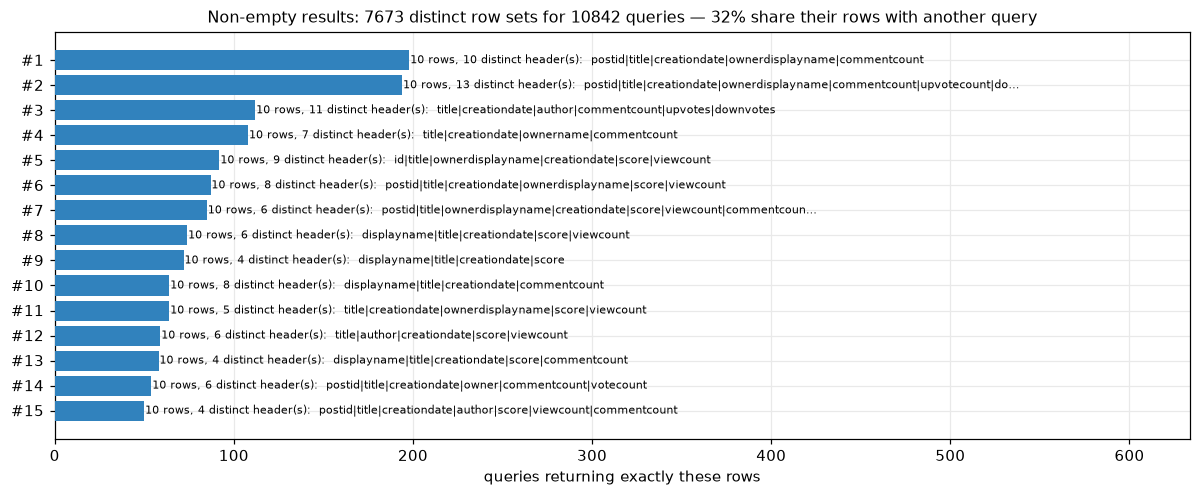

empty results: 944 with 938 distinct headers;  non-empty: 10842 -> 8250 distinct files, 7673 distinct row sets; 256 row sets come back under more than one header


In [14]:
res = O[O["status"].isin(["ok", "capped"])].copy()
res["empty"] = res["parsed"] == 0
ne = res[~res["empty"]]
G_FULL = ne.groupby("full_md5").size()              # same header and rows
G_BODY = ne.groupby("body_md5").size()              # same rows, any column names
ne = ne.assign(g_body=ne["body_md5"].map(G_BODY), g_full=ne["full_md5"].map(G_FULL))
SHARED = (ne["g_body"] > 1).mean()
EMPTY_HDR = res[res["empty"]]["header"].nunique()

top = (ne[ne["g_body"] > 1].groupby("body_md5")
       .agg(queries=("parsed", "size"), rows=("parsed", "first"), headers=("header", "nunique"),
            example=("header", "first"))
       .sort_values("queries", ascending=False))
fig, ax = plt.subplots(figsize=(11, 4.6))
t15 = top.head(15)
ax.barh(range(len(t15)), t15["queries"], color="#3182bd", zorder=3)
for i, r in enumerate(t15.itertuples()):
    ax.text(r.queries + 0.5, i, f"{int(r.rows)} rows, {r.headers} distinct header(s):  "
            f"{r.example[:70]}{'…' if len(r.example) > 70 else ''}", va="center", fontsize=7.5)
ax.set_yticks(range(len(t15))); ax.set_yticklabels([f"#{i + 1}" for i in range(len(t15))])
ax.invert_yaxis(); ax.set_xlim(0, t15["queries"].max() * 3.2)
ax.set_xlabel("queries returning exactly these rows")
ax.set_title(f"Non-empty results: {len(G_BODY)} distinct row sets for {len(ne)} queries — "
             f"{100 * SHARED:.0f}% share their rows with another query", fontsize=10.5)
fig.tight_layout(); savefig(fig, "repeated_results"); plt.show()
print(f"empty results: {int(res['empty'].sum())} with {EMPTY_HDR} distinct headers;  "
      f"non-empty: {len(ne)} -> {len(G_FULL)} distinct files, {len(G_BODY)} distinct row sets; "
      f"{int((top['headers'] > 1).sum())} row sets come back under more than one header")

### 3c. Which posts keep coming back

Most queries return posts, and many sort them the same way (newest, top score, most viewed), so the
same few posts recur across thousands of outputs. Counted over every output with a title column
(`title`, `posttitle`, `questiontitle`, …), on records that split into exactly the header's columns.

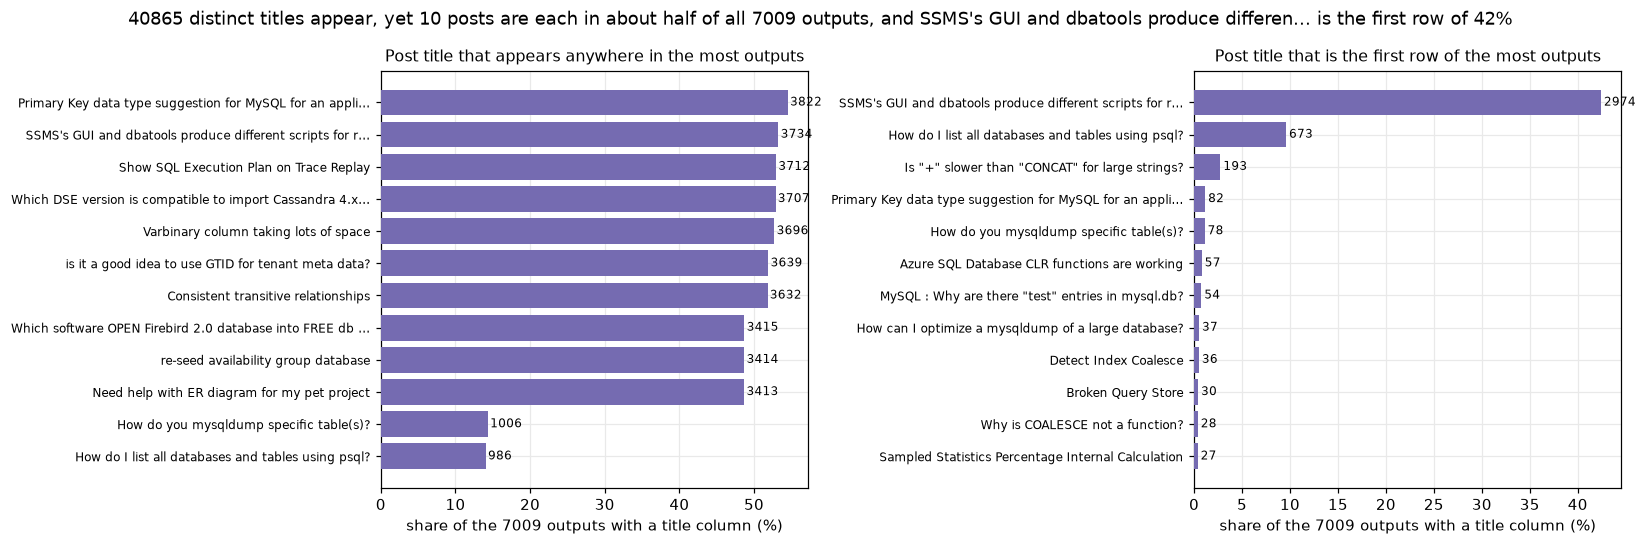

In [15]:
TCOLS = re.compile(r"^(title|posttitle|questiontitle|post_title|question_title)$", re.I)
title_q = collections.Counter()                     # title -> number of outputs it appears in
first_t = collections.Counter()                     # title of the first row
n_tq = 0
for q, r in O[O["status"].isin(["ok", "capped"]) & (O["parsed"] > 0)].iterrows():
    cols = r["header"].split("|")
    idx = [i for i, c in enumerate(cols) if TCOLS.match(c)]
    if not idx:
        continue
    n_tq += 1
    seen = set()
    for j, rec in enumerate(RECS[q]):
        f = rec.split("|")
        if len(f) != len(cols):
            continue
        t = f[idx[0]]
        if t and t not in seen:
            seen.add(t)
        if j == 0 and t:
            first_t[t] += 1
    title_q.update(seen)

TQ = pd.Series(title_q).sort_values(ascending=False)
FT = pd.Series(first_t).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, S, what in [(axes[0], TQ, "appears anywhere in"), (axes[1], FT, "is the first row of")]:
    s = S.head(12)[::-1]
    ax.barh(range(len(s)), 100 * s / n_tq, color="#756bb1", zorder=3)
    for i, v in enumerate(s):
        ax.text(100 * v / n_tq + 0.3, i, f"{v}", va="center", fontsize=8)
    ax.set_yticks(range(len(s))); ax.set_yticklabels([t[:55] + ("…" if len(t) > 55 else "") for t in s.index],
                                                     fontsize=8)
    ax.set_xlabel(f"share of the {n_tq} outputs with a title column (%)")
    ax.set_title(f"Post title that {what} the most outputs", fontsize=10.5)
fig.suptitle(f"{len(TQ)} distinct titles appear, yet {int((TQ >= n_tq / 2.1).sum())} posts are each in about half of "
             f"all {n_tq} outputs, and {FT.index[0][:40]}… is the first row of {100 * FT.iloc[0] / n_tq:.0f}%",
             fontsize=11.5)
fig.tight_layout(); savefig(fig, "repeated_posts"); plt.show()

## 4. Trends against the query text

Empty and capped shares per construct (from the `sqlstorm_analysis` feature table), against the
whole set. A construct well above the dashed line makes that outcome more likely.

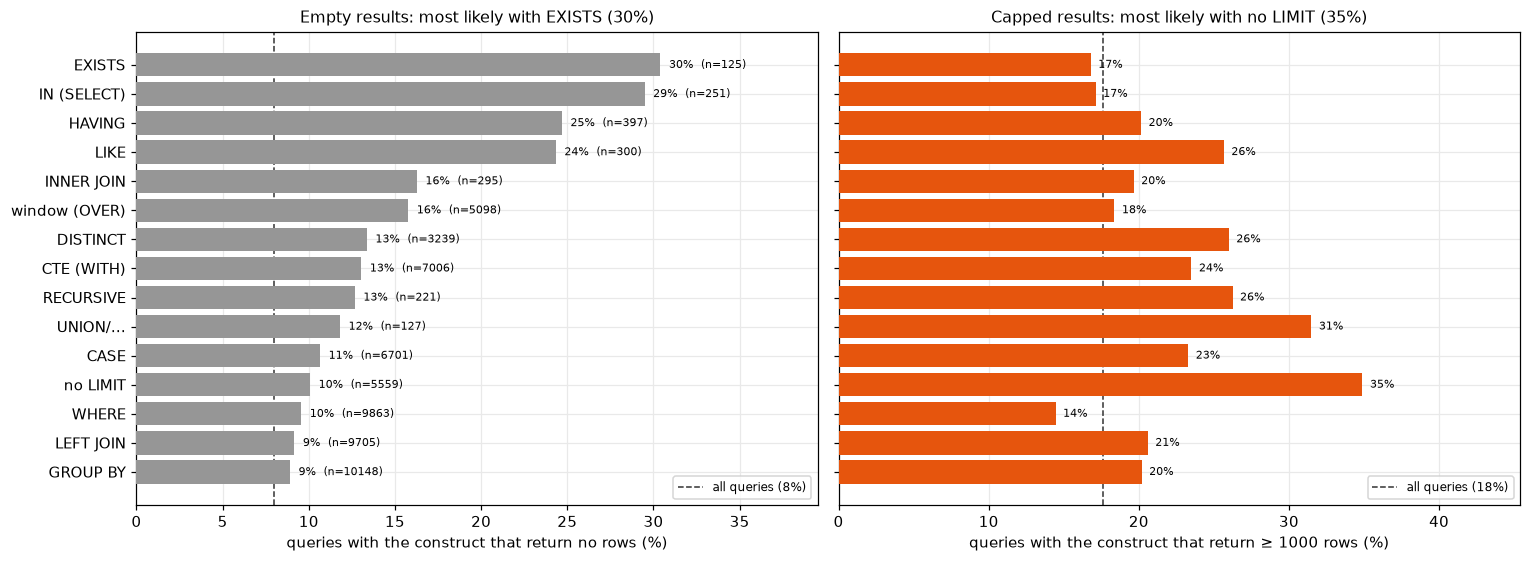

In [16]:
A = O.join(F, how="left")
A["is_empty"] = (A["status"] == "ok") & (A["rows"] == 0)
A["is_cap"] = A["status"] == "capped"
A["no_limit"] = A["limit"].isna()
CONS = [("no LIMIT", "no_limit"), ("WHERE", "has_where"), ("GROUP BY", "has_group"),
        ("HAVING", "has_having"), ("DISTINCT", "has_distinct"), ("CTE (WITH)", "is_cte"),
        ("window (OVER)", "has_window"), ("CASE", "has_case"), ("LEFT JOIN", "join_left"),
        ("INNER JOIN", "join_inner"), ("EXISTS", "has_exists"), ("IN (SELECT)", "has_in_subq"),
        ("LIKE", "has_like"), ("UNION/…", "has_union"), ("RECURSIVE", "has_recursive")]
TR = pd.DataFrame({lbl: {"n": int(A[c].sum()), "empty": 100 * A.loc[A[c].astype(bool), "is_empty"].mean(),
                         "capped": 100 * A.loc[A[c].astype(bool), "is_cap"].mean()}
                   for lbl, c in CONS}).T.sort_values("empty")
BASE = {"empty": 100 * A["is_empty"].mean(), "capped": 100 * A["is_cap"].mean()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, col, color in [(axes[0], "empty", "#969696"), (axes[1], "capped", "#e6550d")]:
    ax.barh(range(len(TR)), TR[col], color=color, zorder=3)
    ax.axvline(BASE[col], color="#333", ls="--", lw=1, label=f"all queries ({BASE[col]:.0f}%)")
    for i, (v, n) in enumerate(zip(TR[col], TR["n"])):
        ax.text(v + 0.5, i, f"{v:.0f}%" + (f"  (n={int(n)})" if col == "empty" else ""), va="center",
                fontsize=7.5)
    ax.set_yticks(range(len(TR))); ax.set_yticklabels(TR.index)
    ax.set_xlabel(f"queries with the construct that return {'no rows' if col == 'empty' else '≥ 1000 rows'} (%)")
    ax.set_xlim(0, TR[col].max() * 1.3); ax.legend(loc="lower right", fontsize=8)
hi = (TR["empty"] - BASE["empty"]).idxmax()
ax0 = axes[0]
ax0.set_title(f"Empty results: most likely with {hi} ({TR.loc[hi, 'empty']:.0f}%)", fontsize=10.5)
hc = (TR["capped"] - BASE["capped"]).idxmax()
axes[1].set_title(f"Capped results: most likely with {hc} ({TR.loc[hc, 'capped']:.0f}%)", fontsize=10.5)
fig.tight_layout(); savefig(fig, "trends_by_construct"); plt.show()

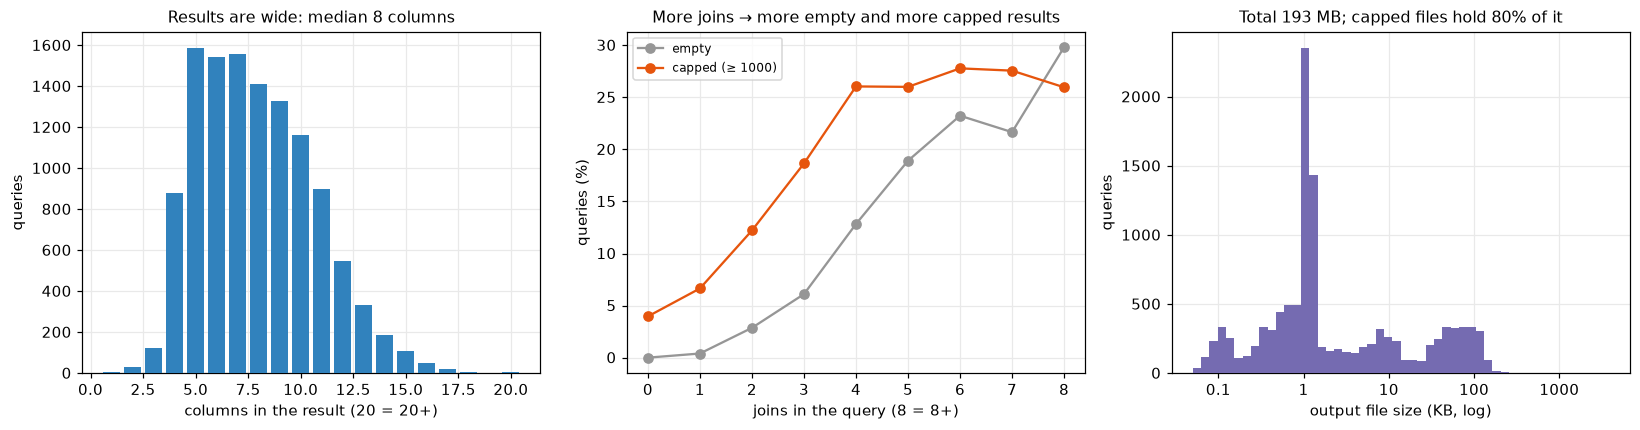

In [17]:
fin = A[A["status"].isin(["ok", "capped"])]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax = axes[0]
nc = fin["ncol"].clip(upper=20).value_counts().sort_index()
ax.bar(nc.index, nc, color="#3182bd", zorder=3)
ax.set_xlabel("columns in the result (20 = 20+)"); ax.set_ylabel("queries")
ax.set_title(f"Results are wide: median {fin['ncol'].median():.0f} columns", fontsize=10.5)
ax = axes[1]
J = fin.groupby(fin["n_join"].clip(upper=8))[["is_empty", "is_cap"]].mean() * 100
ax.plot(J.index, J["is_empty"], "o-", color="#969696", label="empty")
ax.plot(J.index, J["is_cap"], "o-", color="#e6550d", label="capped (≥ 1000)")
ax.set_xlabel("joins in the query (8 = 8+)"); ax.set_ylabel("queries (%)"); ax.legend(fontsize=8)
ax.set_title("More joins → more empty and more capped results", fontsize=10.5)
ax = axes[2]
kb = fin["bytes"] / 1024
ax.hist(np.log10(kb.clip(lower=0.05)), bins=50, color="#756bb1", zorder=3)
ax.set_xticks(np.log10([0.1, 1, 10, 100, 1000])); ax.set_xticklabels(["0.1", "1", "10", "100", "1000"])
ax.set_xlabel("output file size (KB, log)"); ax.set_ylabel("queries")
big = fin.sort_values("bytes").tail(1)
ax.set_title(f"Total {fin['bytes'].sum() / 1e6:.0f} MB; capped files hold "
             f"{100 * fin.loc[fin['is_cap'], 'bytes'].sum() / fin['bytes'].sum():.0f}% of it", fontsize=10.5)
fig.tight_layout(); savefig(fig, "shape_trends"); plt.show()

### 4a. Queries that return nothing

An empty result is a concern for an energy benchmark: the query still costs time and energy, but
the work it was written to do may not be happening — a filter that matches nothing can cut a plan
short, or make it scan everything for no rows. Below: how many there are, what they cost compared
with queries that return rows, why they come back empty, and which of those reasons depend on the
day the query is run.

Costs are the single warm measured copy from the SQLStorm run (15 s timeout); queries that timed out
there are shown separately, since their 15 s is a lower bound.

In [18]:
TIME_UNIT = {"day": 1, "days": 1, "week": 7, "weeks": 7, "month": 30.4, "months": 30.4,
             "year": 365, "years": 365, "hour": 1 / 24, "hours": 1 / 24}
WALLCLOCK = re.compile(r"\bNOW\s*\(|\bCURRENT_(DATE|TIMESTAMP)\b|\bLOCALTIMESTAMP\b", re.I)


def sql_nc(q):                                     # SQL without comments (the header comment holds a date)
    return re.sub(r"--[^\n]*", " ", SQL_RAW[q])


def min_interval_days(s):
    v = [int(n) * TIME_UNIT[u.lower()] for n, u in re.findall(r"INTERVAL\s*'(\d+)\s*([A-Za-z]+)'", s)
         if u.lower() in TIME_UNIT]
    return min(v) if v else np.nan


Z = A[A["status"].isin(["ok", "capped"])].join(TM[["rapl_pkg_j", "elapsed_sec", "pkg_watts_mean", "failed"]],
                                               how="left").copy()
Z["ss_pass"] = (Z["failed"] != 1) & (Z["rapl_pkg_j"] > 0)
Z["wallclock"] = [bool(WALLCLOCK.search(sql_nc(q))) for q in Z.index]
Z["fixed_ref"] = [("2024-10-01 12:34:56" in sql_nc(q)) for q in Z.index]
Z["window_d"] = [min_interval_days(sql_nc(q)) for q in Z.index]
Z["lookup_tbl"] = Z[["tbl_tags", "tbl_linktypes", "tbl_postlinks", "tbl_posthistorytypes",
                     "tbl_closereasontypes"]].any(axis=1)
Z["sql_copy"] = O["sql_md5"].map(O["sql_md5"].value_counts()).reindex(Z.index) > 1

# the data's time span, from the creation dates the outputs themselves show
dates = []
for q, r in O[O["status"].isin(["ok", "capped"]) & (O["parsed"] > 0)].iterrows():
    cols = r["header"].split("|")
    idx = [i for i, c in enumerate(cols) if c.lower() in ("creationdate", "postcreationdate", "questiondate")]
    if idx:
        for rec in RECS[q][:50]:
            f = rec.split("|")
            if len(f) == len(cols) and re.match(r"\d{4}-\d\d-\d\d", f[idx[0]]):
                dates.append(f[idx[0]][:10])
DATA_END = max(dates)
EMP = Z[Z["is_empty"]]
print(f"empty results: {len(EMP)} of {len(Z)} finished queries ({100 * len(EMP) / len(Z):.1f}%), "
      f"{EMP['sql_md5'].nunique()} distinct SQL texts ({int(EMP['sql_copy'].sum())} are copies);  "
      f"latest post creation date in any output: {DATA_END}")

empty results: 944 of 11786 finished queries (8.0%), 940 distinct SQL texts (7 are copies);  latest post creation date in any output: 2024-09-30


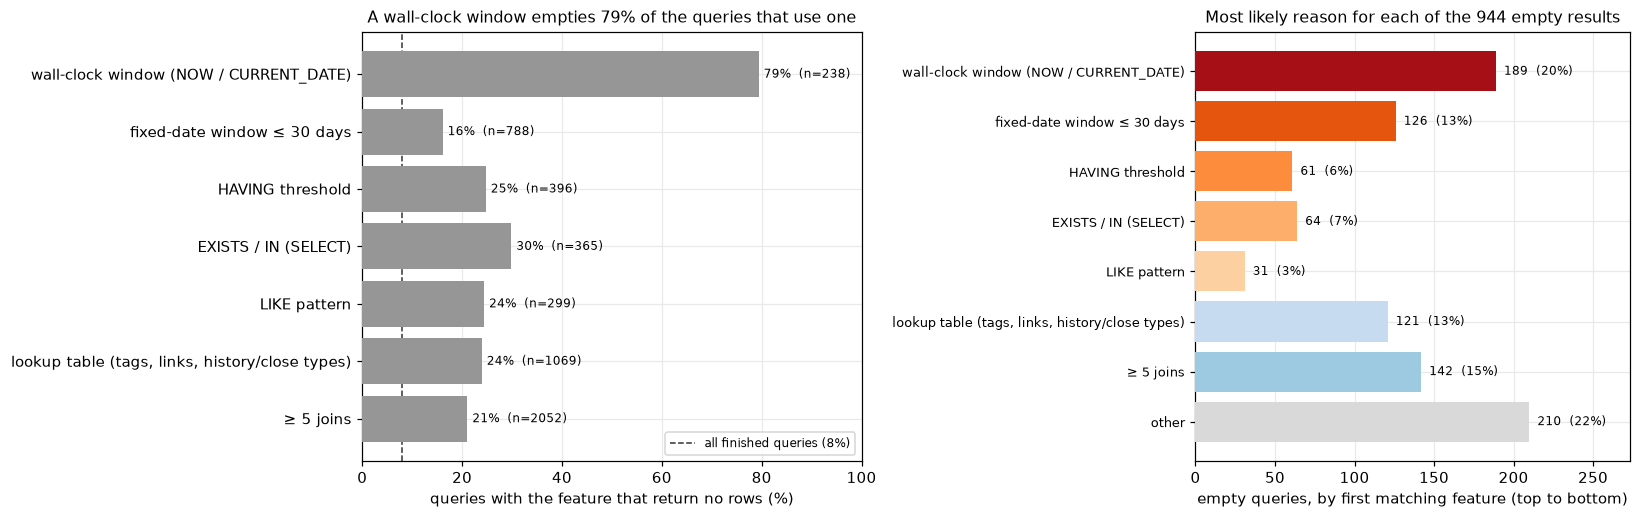

In [19]:
CAUSES = [
    ("wall-clock window (NOW / CURRENT_DATE)", lambda r: r.wallclock),
    ("fixed-date window ≤ 30 days", lambda r: r.fixed_ref and r.window_d <= 31),
    ("HAVING threshold", lambda r: r.has_having),
    ("EXISTS / IN (SELECT)", lambda r: r.has_exists or r.has_in_subq),
    ("LIKE pattern", lambda r: r.has_like),
    ("lookup table (tags, links, history/close types)", lambda r: r.lookup_tbl),
    ("≥ 5 joins", lambda r: r.n_join >= 5),
]
for lbl, f in CAUSES:
    Z[lbl] = [bool(f(r)) for r in Z.itertuples()]
Z["cause"] = "other"
for lbl, _ in CAUSES[::-1]:                        # first matching cause wins
    Z.loc[Z[lbl], "cause"] = lbl
EMP = Z[Z["is_empty"]]
BASE_E = 100 * Z["is_empty"].mean()
CS = pd.DataFrame({lbl: {"n": int(Z[lbl].sum()), "empty %": 100 * Z.loc[Z[lbl], "is_empty"].mean(),
                         "of all empties %": 100 * EMP[lbl].mean()} for lbl, _ in CAUSES}).T
ATTR = EMP["cause"].value_counts().reindex([l for l, _ in CAUSES] + ["other"]).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
y = np.arange(len(CS))
ax.barh(y, CS["empty %"], color="#969696", zorder=3)
ax.axvline(BASE_E, color="#333", ls="--", lw=1, label=f"all finished queries ({BASE_E:.0f}%)")
for i, r in enumerate(CS.itertuples()):
    ax.text(r[2] + 1, i, f"{r[2]:.0f}%  (n={int(r.n)})", va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(CS.index); ax.invert_yaxis()
ax.set_xlim(0, 100); ax.legend(loc="lower right", fontsize=8)
ax.set_xlabel("queries with the feature that return no rows (%)")
ax.set_title(f"A wall-clock window empties {CS.iloc[0]['empty %']:.0f}% of the queries that use one", fontsize=10.5)
ax = axes[1]
ccol = ["#a50f15", "#e6550d", "#fd8d3c", "#fdae6b", "#fdd0a2", "#c6dbef", "#9ecae1", "#d9d9d9"]
ax.barh(range(len(ATTR)), ATTR, color=ccol, zorder=3)
for i, v in enumerate(ATTR):
    ax.text(v + 5, i, f"{v}  ({100 * v / len(EMP):.0f}%)", va="center", fontsize=8)
ax.set_yticks(range(len(ATTR))); ax.set_yticklabels(ATTR.index, fontsize=8.5); ax.invert_yaxis()
ax.set_xlim(0, ATTR.max() * 1.3); ax.set_xlabel("empty queries, by first matching feature (top to bottom)")
ax.set_title(f"Most likely reason for each of the {len(EMP)} empty results", fontsize=10.5)
fig.tight_layout(); savefig(fig, "empty_causes"); plt.show()

**Time windows.** Most SQLStorm queries anchor their date filters at a fixed timestamp,
`'2024-10-01 12:34:56'`, just after the end of the data. About two hundred still use `NOW()` or
`CURRENT_DATE`, so their window is measured back from the day of the run. With data that ends in
2024, a "last 30 days" window run in 2026 finds nothing — and the same query run in 2024 would likely
have returned rows. The left plot splits window queries by anchor and window length. The right plot
compares energy: the wall-clock empties are cheap because the date filter finds nothing early, so
the joins and aggregates the query was written for never run — the measurement is of a different,
much smaller job than the SQL suggests.

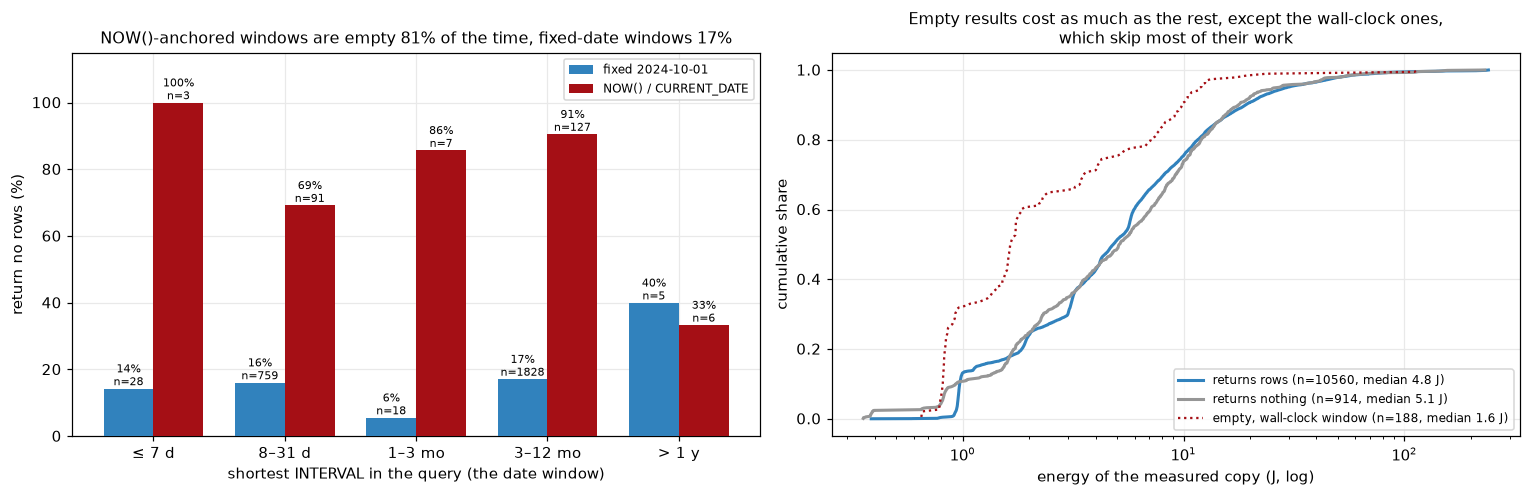

In [20]:
WB = [0, 7.5, 31, 92, 366, 1e9]
WL = ["≤ 7 d", "8–31 d", "1–3 mo", "3–12 mo", "> 1 y"]
W = Z[Z["window_d"].notna() & (Z["wallclock"] | Z["fixed_ref"])].copy()
W["anchor"] = np.where(W["wallclock"], "NOW() / CURRENT_DATE", "fixed 2024-10-01")
W["wbin"] = pd.cut(W["window_d"], WB, labels=WL)
WT = W.groupby(["anchor", "wbin"], observed=False)["is_empty"].agg(["mean", "size"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]
for j, (anc, col) in enumerate([("fixed 2024-10-01", "#3182bd"), ("NOW() / CURRENT_DATE", "#a50f15")]):
    s = WT[WT["anchor"] == anc]
    xx = np.arange(len(WL)) + (j - 0.5) * 0.38
    ax.bar(xx, 100 * s["mean"], 0.38, color=col, label=anc, zorder=3)
    for x_, m, n in zip(xx, s["mean"], s["size"]):
        if n:
            ax.text(x_, 100 * m + 1, f"{100 * m:.0f}%\nn={n}", ha="center", fontsize=7)
ax.set_xticks(range(len(WL))); ax.set_xticklabels(WL)
ax.set_xlabel("shortest INTERVAL in the query (the date window)"); ax.set_ylabel("return no rows (%)")
ax.set_ylim(0, 115); ax.legend(fontsize=8, loc="upper right")
fx = W[W["anchor"] == "fixed 2024-10-01"]["is_empty"].mean()
wc = W[W["anchor"] != "fixed 2024-10-01"]["is_empty"].mean()
ax.set_title(f"NOW()-anchored windows are empty {100 * wc:.0f}% of the time, fixed-date windows {100 * fx:.0f}%",
             fontsize=10.5)

ax = axes[1]
P_ = Z[Z["ss_pass"]]
for flag, col, lbl in [(False, "#3182bd", "returns rows"), (True, "#969696", "returns nothing")]:
    v = np.sort(P_.loc[P_["is_empty"] == flag, "rapl_pkg_j"])
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=col, lw=2,
            label=f"{lbl} (n={len(v)}, median {np.median(v):.1f} J)")
for flag, ls in [(True, ":")]:
    v = np.sort(Z.loc[Z["is_empty"] & Z["wallclock"] & Z["ss_pass"], "rapl_pkg_j"])
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), color="#a50f15", lw=1.5, ls=ls,
            label=f"empty, wall-clock window (n={len(v)}, median {np.median(v):.1f} J)")
ax.set_xscale("log"); ax.set_xlabel("energy of the measured copy (J, log)"); ax.set_ylabel("cumulative share")
ax.legend(fontsize=8, loc="lower right")
ax.set_title("Empty results cost as much as the rest, except the wall-clock ones,\nwhich skip most of their work",
             fontsize=10.5)
fig.tight_layout(); savefig(fig, "empty_windows_cost"); plt.show()

In [21]:
P_ = Z[Z["ss_pass"]]
eP, nP = P_[P_["is_empty"]], P_[~P_["is_empty"]]
TO_E = Z[Z["is_empty"] & (Z["failed"] == 1)]
E_SHARE = eP["rapl_pkg_j"].sum() / P_["rapl_pkg_j"].sum()
T_SHARE = eP["elapsed_sec"].sum() / P_["elapsed_sec"].sum()
COST = pd.DataFrame({"returns rows": nP[["elapsed_sec", "rapl_pkg_j", "pkg_watts_mean"]].median(),
                     "returns nothing": eP[["elapsed_sec", "rapl_pkg_j", "pkg_watts_mean"]].median()}).T
COST.columns = ["median time (s)", "median energy (J)", "median power (W)"]
print(COST.round(2).to_string())
print(f"\nempty results take {100 * E_SHARE:.1f}% of the energy and {100 * T_SHARE:.1f}% of the time of all passing "
      f"queries ({100 * len(eP) / len(P_):.1f}% of them);  {len(TO_E)} more timed out at 15 s in SQLStorm and "
      f"return nothing here (each >= 15 s, {TO_E['rapl_pkg_j'].sum():.0f} J measured before the timeout)")
by = (EMP.assign(E=EMP["rapl_pkg_j"].where(EMP["ss_pass"]))
      .groupby("cause").agg(queries=("E", "size"), median_J=("E", "median"), total_J=("E", "sum"),
                            median_s=("elapsed_sec", "median"), sqlstorm_timeouts=("failed", lambda s: int((s == 1).sum())))
      .reindex(ATTR.index))
print("\nby most likely reason:\n" + by.round(2).to_string())
print("\nmost expensive empty results:")
print(EMP.sort_values("rapl_pkg_j", ascending=False).head(8)[["rapl_pkg_j", "elapsed_sec", "failed", "n_join",
                                                              "cause"]].round(2).to_string())

EMP_OUT = EMP[["rapl_pkg_j", "elapsed_sec", "failed", "cause", "wallclock", "fixed_ref", "window_d", "n_join",
               "has_having", "has_like", "has_exists", "has_in_subq", "lookup_tbl", "sql_copy"]].rename(
    columns={"rapl_pkg_j": "sqlstorm_energy_j", "elapsed_sec": "sqlstorm_elapsed_s", "failed": "sqlstorm_timeout"})
EMP_OUT.to_csv("csv/sqlstorm_stackoverflow_empty_queries.csv")
WC = Z[Z["wallclock"]]
print(f"\nwall-clock queries overall: {len(WC)} ({int(WC['is_empty'].sum())} empty, "
      f"{int((~WC['is_empty']).sum())} return rows today — their result also changes with the run date)")
ex = EMP[EMP["wallclock"]].index.min()
m = re.search(r"[^\n]*(NOW\s*\(|CURRENT_DATE|CURRENT_TIMESTAMP)[^\n]*", sql_nc(ex), re.I)
print(f"example q{ex}: {m.group(0).strip() if m else ''}")

                 median time (s)  median energy (J)  median power (W)
returns rows                0.72               4.81              7.19
returns nothing             0.71               5.13              7.81

empty results take 7.9% of the energy and 7.7% of the time of all passing queries (8.0% of them);  30 more timed out at 15 s in SQLStorm and return nothing here (each >= 15 s, 4342 J measured before the timeout)

by most likely reason:
                                                 queries  median_J  total_J  median_s  sqlstorm_timeouts
cause                                                                                                   
wall-clock window (NOW / CURRENT_DATE)               189      1.65   885.49      0.19                  1
fixed-date window ≤ 30 days                          126      5.70  1103.59      0.80                  4
HAVING threshold                                      61      7.09   464.81      1.04                  5
EXISTS / IN (SELECT)        

## 5. Run time

Files are written in query-name order, so the gap between consecutive file modification times is each
query's wall time (sudo + psql start-up + the query until done, timed out, or stopped by the cap).
Compared with the single warm copy measured in the SQLStorm run (`sqlstorm_analysis`, 15 s timeout).

run: 4.61 h for 11794 queries; on complete queries that passed in SQLStorm the output run takes 0.73x the measured copy (median; log-log r = 0.985)
status        capped    ok  timeout    All
ss_status                                 
pass            1958  9516        0  11474
timeout 15 s     116   196        8    320
All             2074  9712        8  11794


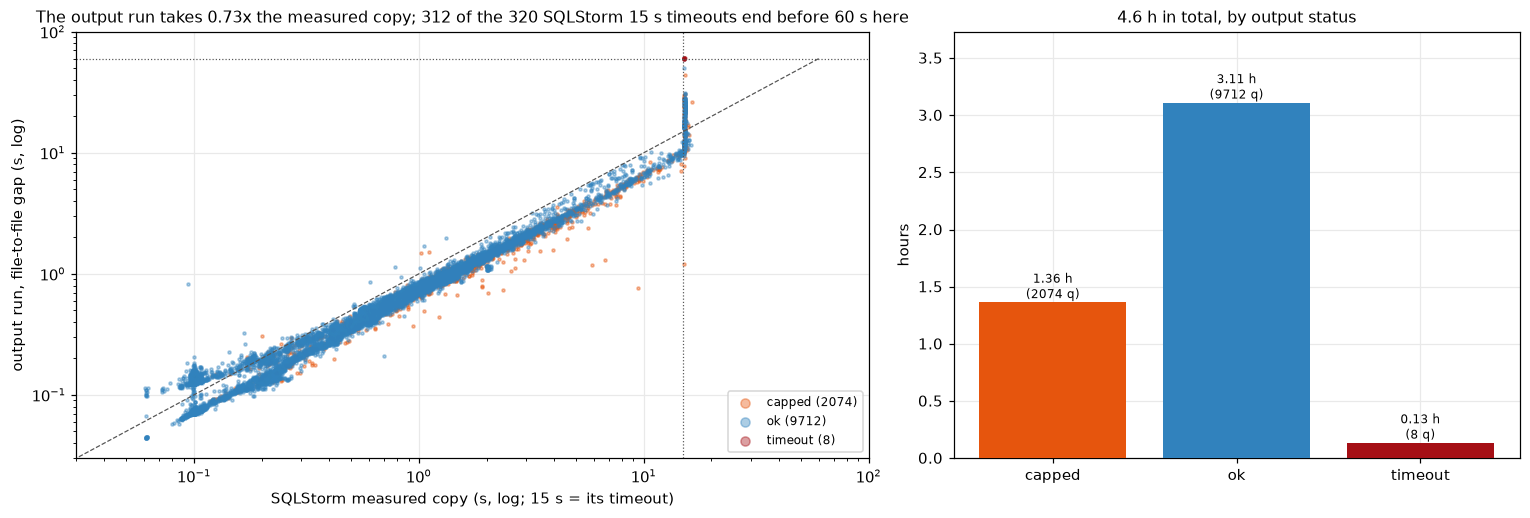

the 320 SQLStorm 15 s timeouts here: ok 196, capped 116, timeout 8; median gap 17.7 s


In [22]:
mt = pd.read_csv(CACHE / f"{DB}.mtimes.tsv", sep="\t", header=None, names=["file", "mtime"])
mt["qid"] = mt["file"].str.removesuffix(".txt").astype(int)
mt = mt.set_index("qid").loc[[int(f.stem) for f in FILES]]     # runner order = sorted file names
start = pd.Timestamp(re.search(r"detach\.sh start (\S+)", con).group(1)).timestamp()
O["run_s"] = pd.Series(np.diff(np.r_[start, mt["mtime"].to_numpy()]), index=mt.index)  # aligned by qid
WALL_H = (mt["mtime"].iloc[-1] - start) / 3600

T = pd.read_csv(TIMING)
T = T[T["phase"] == "measured"].copy()
T["qid"] = T["query"].str.extract(r"(\d+)\.sql$")[0].astype(int)
T = T.drop_duplicates("qid", keep="last").set_index("qid")
T["ss_status"] = np.where(T["failed"] != 1, "pass", np.where(T["elapsed_sec"] >= 14.5, "timeout 15 s", "error"))
B = O.join(T[["elapsed_sec", "ss_status"]], how="left")

both = B[(B["ss_status"] == "pass") & (B["status"] == "ok")]
RATIO = (both["run_s"] / both["elapsed_sec"]).median()
RCORR = np.corrcoef(np.log(both["run_s"]), np.log(both["elapsed_sec"]))[0, 1]
XT = pd.crosstab(B["ss_status"], B["status"], margins=True)
print(f"run: {WALL_H:.2f} h for {len(O)} queries; on complete queries that passed in SQLStorm the output run "
      f"takes {RATIO:.2f}x the measured copy (median; log-log r = {RCORR:.3f})")
print(XT.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
scol = {"ok": "#3182bd", "capped": "#e6550d", "timeout": "#a50f15", "error": "#a50f15"}
for s, g in B.groupby("status"):
    ax.scatter(g["elapsed_sec"].clip(lower=1e-3), g["run_s"].clip(lower=1e-2), s=4, alpha=0.4,
               color=scol[s], label=f"{s} ({len(g)})", rasterized=True)
ax.plot([1e-3, 60], [1e-3, 60], color="#555", lw=0.8, ls="--")
ax.axvline(15, color="#555", lw=0.8, ls=":"); ax.axhline(60, color="#555", lw=0.8, ls=":")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("SQLStorm measured copy (s, log; 15 s = its timeout)")
ax.set_ylabel("output run, file-to-file gap (s, log)")
ax.legend(fontsize=8, markerscale=3)
ax.set_xlim(0.03, 100); ax.set_ylim(0.03, 100)
n_fin = int(((B["ss_status"] == "timeout 15 s") & (B["status"] != "timeout")).sum())
ax.set_title(f"The output run takes {RATIO:.2f}x the measured copy; {n_fin} of the "
             f"{int((B['ss_status'] == 'timeout 15 s').sum())} SQLStorm 15 s timeouts end before 60 s here",
             fontsize=10.5)
ax = axes[1]
TB = B.groupby("status")["run_s"].sum() / 3600
ax.bar(TB.index, TB, color=[scol[s] for s in TB.index], zorder=3)
for i, (s, v) in enumerate(TB.items()):
    ax.text(i, v, f"{v:.2f} h\n({int((B['status'] == s).sum())} q)", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("hours"); ax.set_ylim(0, TB.max() * 1.2)
ax.set_title(f"{WALL_H:.1f} h in total, by output status", fontsize=10.5)
fig.tight_layout(); savefig(fig, "run_time"); plt.show()

TO15 = B[B["ss_status"] == "timeout 15 s"]
print(f"the {len(TO15)} SQLStorm 15 s timeouts here: " +
      ", ".join(f"{k} {v}" for k, v in TO15["status"].value_counts().items()) +
      f"; median gap {TO15['run_s'].median():.1f} s")

## 6. Export and summary

`csv/sqlstorm_stackoverflow_outputs.csv`, one row per query: status, rows (a lower bound when
capped), complete records kept, columns, bytes, multi-line flag, duplicate rows, how many queries
share the same row set, outer LIMIT, run time and the SQLStorm outcome.

In [23]:
from IPython.display import Markdown, display
EX = B.copy()
EX["rows_at_least"] = EX["status"] == "capped"
EX["same_rows_as_n_queries"] = EX["body_md5"].map(G_BODY).fillna(0).astype(int) - 1
EX.loc[EX["parsed"].fillna(0) == 0, "same_rows_as_n_queries"] = np.nan
EX["all_rows_identical"] = EX.index.isin(SAME.index)
EX["identical_output_group"] = O["ident_group"]
EX["sql_copies"] = O["sql_md5"].map(O["sql_md5"].value_counts()) - 1
cols = ["status", "rows", "rows_at_least", "parsed", "ncol", "bytes", "multiline", "dup_rows", "all_rows_identical",
        "identical_output_group", "sql_copies",
        "same_rows_as_n_queries", "limit", "run_s", "ss_status", "elapsed_sec"]
EX[cols].rename(columns={"parsed": "records_kept", "elapsed_sec": "sqlstorm_elapsed_s",
                         "ss_status": "sqlstorm_status"}).round(3).to_csv("csv/sqlstorm_stackoverflow_outputs.csv")

n = len(O); st = O["status"].value_counts()
lines = [
    f"* **{n} outputs**, {WALL_H:.1f} h. {st.get('ok', 0)} complete ({100 * st.get('ok', 0) / n:.1f}%), "
    f"**{CAP_N} hit the 1000-row cap ({100 * CAP_N / n:.1f}%)**, {st.get('timeout', 0)} timed out at 60 s"
    + (f", {st.get('error', 0)} other errors" if st.get('error', 0) else "") + ".",
    f"* **The cap is a line cap.** {CAP_FULL} capped outputs hold 1000 complete rows (true result ≥ 1000); "
    f"{CAP_SHORT} were cut earlier because values with newlines span lines. "
    f"{int(cap['limit'].isna().sum())} of the capped queries "
    f"have no LIMIT at all.",
    f"* **Empty results:** {len(EMP)} queries ({100 * len(EMP) / len(Z):.0f}%) return no rows and are no cheaper "
    f"than the rest (median {COST.iloc[1, 1]:.1f} J vs {COST.iloc[0, 1]:.1f} J; {100 * E_SHARE:.1f}% of all passing "
    f"energy, plus {len(TO_E)} SQLStorm 15 s timeouts that return nothing). The biggest single reason: "
    f"{int(Z['wallclock'].sum())} queries filter on NOW()/CURRENT_DATE, and {CS.iloc[0]['empty %']:.0f}% of them are "
    f"empty because the data ends {DATA_END} — run in 2024 most would likely have returned rows, so their result and cost "
    f"depend on the run date.",
    f"* **LIMIT** decides the shape: {100 * FILL:.0f}% of finished queries with a LIMIT return exactly that many rows.",
    f"* **Repeated rows:** {100 * DUP_ANY:.0f}% of multi-row outputs contain duplicate rows, "
    f"{N_SAME} are one row repeated in full ({N_SAME_CAP} of them 1000 times at the cap, "
    f"{int((SAME['empty_fields'] >= 0.5).sum())} mostly NULL); {int(SAME['join_left'].sum())} of them use "
    f"LEFT JOINs and {int(SAME['has_window'].sum())} window functions, which repeat a row once per joined "
    f"row unless the outer query collapses them.",
    f"* **Identical outputs across queries:** {len(IDQ)} queries fall in {IDQ['group'].nunique()} groups of "
    f"byte-identical outputs. {KC.iloc[0]} groups ({KQ.iloc[0]} queries) are copies of one query: the corpus has "
    f"only {SQLN.nunique()} distinct SQL texts for {len(O)} queries ({N_SQL_DUP} queries in {N_SQL_SETS} copy sets), "
    f"and every copy returns the same file. {KC.iloc[1] + KC.iloc[2]} groups contain genuinely different SQL "
    f"({len(PAIRS)} pairs, median token similarity {PAIRS['sim'].median():.2f} vs {RAND.median():.2f} for random pairs).",
    f"* **Cost of different SQL with the same output:** usually the same (median pair ratio {DIFF['rE'].median():.3f}x "
    f"vs {NOISE['rE'].median():.3f}x between copies), but {len(REAL)} of {len(VG)} groups differ beyond noise and "
    f"{int((VG['rE'] >= 2).sum())} by 2x or more (max {VG['rE'].max():.1f}x energy, {VG['rt'].max():.1f}x time).",
    f"* **Repeated results:** {len(ne)} non-empty outputs have only {len(G_BODY)} distinct row sets; "
    f"{100 * SHARED:.0f}% of them return exactly the rows another query returns, the largest group "
    f"{int(top['queries'].iloc[0])} queries. The same posts dominate: "
    f"*{FT.index[0][:60]}* is the first row of {FT.iloc[0]} outputs.",
    f"* **Run time:** {WALL_H:.1f} h; complete queries take {RATIO:.2f}x their SQLStorm measured copy "
    f"(r = {RCORR:.2f} in log-log). Of the {len(TO15)} SQLStorm 15 s timeouts, "
    f"{int((TO15['status'] == 'ok').sum())} complete here (median {TO15.loc[TO15['status'] == 'ok', 'run_s'].median():.0f} s), "
    f"{int((TO15['status'] == 'capped').sum())} are stopped by the cap and {int((TO15['status'] == 'timeout').sum())} "
    f"still time out at 60 s.",
    f"* **Runner bookkeeping:** `output_runner` reported {len(RUNNER_FAILED)} FAILED, but "
    f"{len(FALSE_FAIL)} of those are result rows starting with `ERROR:` (post titles), not failures.",
    f"* Record rebuild agrees with psql's own row count on {100 * PARSE_OK:.2f}% of complete outputs.",
]
display(Markdown("\n".join(lines)))

* **11794 outputs**, 4.6 h. 9712 complete (82.3%), **2074 hit the 1000-row cap (17.6%)**, 8 timed out at 60 s.
* **The cap is a line cap.** 1974 capped outputs hold 1000 complete rows (true result ≥ 1000); 100 were cut earlier because values with newlines span lines. 1940 of the capped queries have no LIMIT at all.
* **Empty results:** 944 queries (8%) return no rows and are no cheaper than the rest (median 5.1 J vs 4.8 J; 7.9% of all passing energy, plus 30 SQLStorm 15 s timeouts that return nothing). The biggest single reason: 238 queries filter on NOW()/CURRENT_DATE, and 79% of them are empty because the data ends 2024-09-30 — run in 2024 most would likely have returned rows, so their result and cost depend on the run date.
* **LIMIT** decides the shape: 89% of finished queries with a LIMIT return exactly that many rows.
* **Repeated rows:** 5% of multi-row outputs contain duplicate rows, 31 are one row repeated in full (10 of them 1000 times at the cap, 2 mostly NULL); 31 of them use LEFT JOINs and 27 window functions, which repeat a row once per joined row unless the outer query collapses them.
* **Identical outputs across queries:** 3050 queries fall in 452 groups of byte-identical outputs. 258 groups (1043 queries) are copies of one query: the corpus has only 9519 distinct SQL texts for 11794 queries (2727 queries in 452 copy sets), and every copy returns the same file. 194 groups contain genuinely different SQL (567 pairs, median token similarity 0.94 vs 0.28 for random pairs).
* **Cost of different SQL with the same output:** usually the same (median pair ratio 1.015x vs 1.012x between copies), but 55 of 194 groups differ beyond noise and 5 by 2x or more (max 2.9x energy, 5.4x time).
* **Repeated results:** 10842 non-empty outputs have only 7673 distinct row sets; 32% of them return exactly the rows another query returns, the largest group 198 queries. The same posts dominate: *SSMS's GUI and dbatools produce different scripts for restor* is the first row of 2974 outputs.
* **Run time:** 4.6 h; complete queries take 0.73x their SQLStorm measured copy (r = 0.99 in log-log). Of the 320 SQLStorm 15 s timeouts, 196 complete here (median 18 s), 116 are stopped by the cap and 8 still time out at 60 s.
* **Runner bookkeeping:** `output_runner` reported 18 FAILED, but 10 of those are result rows starting with `ERROR:` (post titles), not failures.
* Record rebuild agrees with psql's own row count on 99.78% of complete outputs.